In [ ]:

!pip install numpyro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 13.0 MB/s eta 0:00:00


In [ ]:
# check this if running on GPU
import jax
jax.default_backend()

'gpu'

In [ ]:
jax.devices()

[CudaDevice(id=0)]

In [ ]:
# Set up file system
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:

import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import os
import arviz as az
from sklearn.preprocessing import StandardScaler
import pandas as pd
import xarray as xr
import scipy.stats as stats


In [ ]:
import pymc as pm
import pytensor.tensor as pt
import numpy as np
import logging

logging.basicConfig(level=logging.INFO)
SEED = 42

rng = np.random.default_rng(SEED)

def compute_metrics(y_true, y_pred, label=""):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    pearson_r,  pearson_p  = stats.pearsonr(y_true, y_pred)
    spearman_r, spearman_p = stats.spearmanr(y_true, y_pred)
    print(f"\n{'─'*48}")
    if label:
        print(f"  {label}")
    print(f"  N        : {mask.sum()}")
    print(f"  RMSE     : {rmse:.4f}")
    print(f"  Pearson  : r={pearson_r:.4f}  p={pearson_p:.3g}")
    print(f"  Spearman : r={spearman_r:.4f}  p={spearman_p:.3g}")
    print(f"{'─'*48}\n")
    return dict(n=int(mask.sum()), rmse=rmse,
                pearson_r=pearson_r,  pearson_p=pearson_p,
                spearman_r=spearman_r, spearman_p=spearman_p)

# ─────────────────────────────────────────────────────────────
# STRATEGY 1 — RANDOM MASK SPLIT
# Hides individual observations regardless of peptide.
# Tests interpolation: model has seen all peptides during training.
# ─────────────────────────────────────────────────────────────

def split_random_mask(long_df, holdout_frac=0.20, random_state=42):
    rand_num_gen  = np.random.default_rng(random_state)
    n        = len(long_df)
    test_idx = rand_num_gen.choice(n, size=int(n * holdout_frac), replace=False)
    mask     = np.zeros(n, dtype=bool)
    mask[test_idx] = True

    train_df = long_df[~mask].copy()
    test_df  = long_df[ mask].copy()

    print(f"[random mask]  train obs={len(train_df)}  test obs={len(test_df)}")
    return train_df, test_df

# ─────────────────────────────────────────────────────────────
# STRATEGY 2 — HELD-OUT PEPTIDE SPLIT
# Holds out entire peptides from training.
# Tests generalization: model must predict from features alone.
# ─────────────────────────────────────────────────────────────

def split_holdout_peptides(long_df, holdout_frac=0.20, random_state=42):
    #set holdouts
    peptides  = long_df["Peptide ID"].unique()
    rand_num_gen = np.random.default_rng(random_state)
    n_holdout = max(1, int(len(peptides) * holdout_frac))
    held_out  = set(rand_num_gen.choice(peptides, size=n_holdout, replace=False))

    train_df = long_df[~long_df["Peptide ID"].isin(held_out)].copy()
    test_df  = long_df[ long_df["Peptide ID"].isin(held_out)].copy()

    print(f"[peptide holdout]  train peptides={train_df['Peptide ID'].nunique()}"
          f"  test peptides={test_df['Peptide ID'].nunique()}  ({len(test_df)} obs)")
    return train_df, test_df

class Hybrid_PMF:
    """Hybrid Probabilistic Matrix Factorization model for MIC prediction."""

    def __init__(self, obs_df, pc_df, esm_df, species_to_genus_idx, dim=10,
                 horseshoe=True, include_esm=True, non_centered=False,
                 linreg=False):
        """
        :param obs_df: DataFrame with ['Peptide ID', 'Target Species', 'mic']
                       (Uses LONG format)
        :param pc_df: pd.DataFrame shape (N_peptides, 12)
        :param esm_df: pd.DataFrame shape (N_peptides, 1280)
        :param species_to_genus_idx: 1D array mapping species_id -> genus_id
        :param dim: Latent factors (K)
        """
        self.name = "Hybrid_PMF"
        self.dim = dim

        # Clean Data
        species_dict = {species: idx for idx, species in enumerate(obs_df['Target Species'].unique())}
        peptide_dict = {peptide: idx for idx, peptide in enumerate(obs_df['Peptide ID'].unique())}
        self.species_dict = species_dict
        self.peptide_dict = peptide_dict

        obs_df['species_idx'] = obs_df['Target Species'].map(species_dict)
        obs_df['peptide_idx'] = obs_df['Peptide ID'].map(peptide_dict)

        pc_df['original_idx'] = pc_df.index
        esm_df['original_idx'] = esm_df.index
        pc_df.index = pc_df.index.map(peptide_dict)
        esm_df.index = esm_df.index.map(peptide_dict)
        self.pc_df = pc_df
        self.esm_df = esm_df

        # Extract Data
        obs_peptide_idx = obs_df['peptide_idx'].values
        obs_species_idx = obs_df['species_idx'].values
        obs_mic = obs_df['mic'].values
        # Get the unique integer indices (0 to n_peptides-1) in order
        unique_pep_idx = np.sort(np.unique(obs_peptide_idx))

        # Slice the dataframes using the unique indices
        # And drop the original_idx column
        pc_input = pc_df.loc[unique_pep_idx].iloc[:, :-1].values
        esm_input = esm_df.loc[unique_pep_idx].iloc[:, :-1].values

        n_peptides = len(np.unique(obs_peptide_idx))
        n_species = len(np.unique(obs_species_idx))
        n_genera = len(np.unique(species_to_genus_idx))
        n_obs = len(obs_mic)

        self.idata = None
        self.idata_vi = None

        logging.info("Building the PMF model...")

        with pm.Model(
                coords={
                    "peptide": range(n_peptides),
                    "species": range(n_species),
                    "genus": range(n_genera),
                    "latent_factor": range(dim),
                    "obs_id": range(n_obs),
                    "phys_chem": range(pc_input.shape[1]),
                    "esm": range(esm_input.shape[1])
                }
        ) as pmf:
            # --- DATA CONTAINERS ---
            pep_idx_ = pm.Data("pep_idx", obs_peptide_idx, dims="obs_id")
            spec_idx_ = pm.Data("spec_idx", obs_species_idx, dims="obs_id")
            mic_ = pm.Data("mic", obs_mic, dims="obs_id")

            X_pc = pm.Data("X_pc", pc_input, dims=("peptide", "phys_chem"))
            X_esm = pm.Data("X_esm", esm_input, dims=("peptide", "esm"))

            if not linreg:

                # --- HYBRID PEPTIDE MAPPING (u_i) ---
                # 1. Physical Features (Standard Weakly Informative Prior)
                B_pc = pm.Normal("B_pc", mu=0, sigma=1, dims=("phys_chem", "latent_factor"))

                if include_esm:
                    if horseshoe:
                        # 2. ESM Features (COLUMN-WISE HORSESHOE PRIOR - Non-Centered)
                        # Global shrinkage
                        tau_esm = pm.HalfCauchy("tau_esm", beta=1)
                        # Local shrinkage (One per ESM feature, applied across all K dims)
                        lambda_esm = pm.HalfCauchy("lambda_esm", beta=1, dims="esm")
                        # Raw weights
                        B_esm_raw = pm.Normal("B_esm_raw", mu=0, sigma=1, dims=("esm", "latent_factor"))
                        # Decoupled matrix multiplication
                        B_esm = pm.Deterministic(
                            "B_esm",
                            B_esm_raw * (tau_esm * lambda_esm)[:, None],
                            dims=("esm", "latent_factor")
                        )
                    else:
                        B_esm = pm.Normal("B_esm", mu=0, sigma=1, dims=("esm", "latent_factor"))

                    # 3. Calculate Latent Peptides (U) via Matrix Dot Product
                    # U is shape (N_peptides, K)
                    U = pm.Deterministic("U", pt.dot(X_pc, B_pc) + pt.dot(X_esm, B_esm), dims=("peptide", "latent_factor"))
                else:
                    U = pm.Deterministic("U", pt.dot(X_pc, B_pc), dims=("peptide", "latent_factor"))

                # --- TAXONOMIC HIERARCHY (v_j) ---  TODO - add back?
                # Genus-level baseline factors
                # V_genus = pm.Normal("V_genus", mu=0, sigma=1, dims=("genus", "latent_factor"))
                # Species-level factors (Centered on their Genus)
                # sigma_species = pm.HalfNormal("sigma_species",
                #                               sigma=1) #, dims=("latent_factor")) # shape D or 1?

                # if non_centered:
                #     # --- NON-CENTERED LATENT VECTORS ---
                #     V_species_raw = pm.Normal("V_species_raw", mu=0, sigma=1, dims=("species", "latent_factor"))
                #     # Broadcasting the scale across the latent dimensions
                #     V_species = pm.Deterministic("V_species", V_species_raw * sigma_species, dims=("species", "latent_factor"))
                # else:
                #     V_species = pm.Normal(
                #         "V_species",
                #         mu=0,  # V_genus[species_to_genus_idx],
                #         sigma=sigma_species,
                #         dims=("species", "latent_factor")
                #     )

                #### hard coded sigma to avoid correlation with learned variance in U ####
                V_species = pm.Normal("V_species", mu=0, sigma=1, dims=("species", "latent_factor"))


            # --- INTERCEPTS ---
            ## global_mu removed to avoid centering issue (where sampler can add to mu and subtract elsewhere)
            ## required that I subtract the mean from the dataset before inputting
            # data_mean = np.mean(obs_mic)
            # global_mu = pm.Normal("global_mu", mu=data_mean, sigma=5, initval=data_mean)

            # Species Intercept (Hierarchical Intrinsic Resistance)  TODO - make hierarchical?
            # beta_genus = pm.Normal("beta_genus", mu=0, sigma=1, dims="genus")
            beta_sigma_species = pm.HalfNormal("beta_sigma_species", sigma=1)
            if non_centered:
                # 1. Sample raw from a standard normal
                beta_species_raw = pm.Normal("beta_species_raw", mu=0, sigma=1, dims="species")
                # 2. Scale it deterministically
                beta_species = pm.Deterministic("beta_species", beta_species_raw * beta_sigma_species, dims="species")
            else:
                beta_species = pm.ZeroSumNormal("beta_species",
                                        #mu=0,  #beta_genus[species_to_genus_idx],
                                        dims="species", sigma=beta_sigma_species)

            # Peptide Intercept (Cold-start friendly mapping)
            w0_pc = pm.Normal("w0_pc", mu=0, sigma=1, dims="phys_chem")

            if include_esm:
                w0_esm = pm.Normal("w0_esm", mu=0, sigma=0.1, dims="esm")
                alpha_peptide = pm.Deterministic("alpha_peptide", pt.dot(X_pc, w0_pc) + pt.dot(X_esm, w0_esm),
                                                dims="peptide")
            else:
                alpha_peptide = pm.Deterministic("alpha_peptide", pt.dot(X_pc, w0_pc),
                                                dims="peptide")

            # --- LIKELIHOOD ---
            if not linreg:
                # 1. Gather the relevant parameters for the observed data points
                U_obs = U[pep_idx_]  # Shape (N_obs, K)
                V_obs = V_species[spec_idx_]  # Shape (N_obs, K)

                # 2. Calculate interaction term using batched dot product along the K dimension
                interaction = (U_obs * V_obs).sum(axis=-1)
            else:
                # Use pep_idx_.shape[0] to get the size of the tensor
                interaction = pt.zeros(pep_idx_.shape[0])

            # 3. Build the predicted mean
            mu_obs = alpha_peptide[pep_idx_] + beta_species[spec_idx_] + interaction #+ global_mu

            # 4. Observation Noise
            sigma_obs = pm.HalfNormal("sigma_obs", sigma=1)

            # 5. Final Distribution (assuming output is not in log space yet)
            pm.Normal("MIC_obs", mu=mu_obs, sigma=sigma_obs, observed=mic_, dims="obs_id")

        self.model = pmf
        logging.info("Done building the PMF model.")

    # Draw MCMC samples.
    def draw_samples(self, **kwargs):
        with self.model:
            self.idata = pm.sample(**kwargs)
        return self.idata

    def var_inference(self, **kwargs):
        with self.model:
            self.idata_vi = pm.fit(**kwargs)
        return self.idata_vi

    def predict_new_peptides(self, new_long_df, return_full_posterior=False):
        # 1. Identify the unique peptides in this specific prediction batch
        predict_peps = new_long_df["Peptide ID"].unique()

        # 2. Extract their features from your master dataframes
        # Assumes original_idx is a column containing the Peptide IDs
        pc_df_predict = self.pc_df[self.pc_df['original_idx'].isin(predict_peps)]
        esm_df_predict = self.esm_df[self.esm_df['original_idx'].isin(predict_peps)]

        # 3. Create a LOCAL dictionary mapping to 0, 1, 2... N
        # This prevents the PyMC IndexError trap
        local_pep_dict = {pep: i for i, pep in enumerate(predict_peps)}

        # 4. Map the observation dataframe to these local indices
        obs_peptide_idx = new_long_df["Peptide ID"].map(local_pep_dict).values

        # 5. Extract feature matrices in the exact order of the local dictionary
        # Make sure to set the index to Peptide ID temporarily so .loc alignment works perfectly
        pc_input = pc_df_predict.set_index('original_idx').loc[predict_peps]
        esm_input = esm_df_predict.set_index('original_idx').loc[predict_peps]

        # Ensure all target species exist in the training dictionary
        assert len(set(new_long_df["Target Species"]) - set(self.species_dict.keys())) == 0, \
            "Cannot predict for a species not in the training set!"

        with self.model:
            pm.set_data(
                {
                    "pep_idx":  obs_peptide_idx,
                    "spec_idx": new_long_df["Target Species"].map(self.species_dict).values,
                    "mic":      np.ones(len(new_long_df)), # Dummy values for shape
                    "X_pc":     pc_input.values,
                    "X_esm":    esm_input.values,
                },
                coords={
                    "obs_id":  range(len(new_long_df)),
                    "peptide": range(len(predict_peps)),
                },
            )

            idata = self.idata if hasattr(self, 'idata') and self.idata else self.idata_vi
            ppc = pm.sample_posterior_predictive(idata, extend_inferencedata=False)

        raw = ppc.posterior_predictive["MIC_obs"]
        return raw if return_full_posterior else raw.mean(("chain", "draw")).values

    def evaluate(self, test_df, label=""):
        # check for MCMC first
        y_pred = self.predict_new_peptides(test_df)
        y_true = test_df["mic"].values
        return compute_metrics(y_true, y_pred, label=label)

    def _norms(self):
        """Return norms of latent variables at each step in the
        sample trace. These can be used to monitor convergence
        of the sampler.
        """
        # check for MCMC first
        idata = self.idata if self.idata else self.idata_vi
        norms = dict()
        norms["U"] = xr.apply_ufunc(
            np.linalg.norm,
            idata.posterior["U"],
            input_core_dims=[["peptide", "latent_factor"]],
            kwargs={"ord": "fro", "axis": (-2, -1)},
        )
        norms["V"] = xr.apply_ufunc(
            np.linalg.norm,
            idata.posterior["V_species"],
            input_core_dims=[["species", "latent_factor"]],
            kwargs={"ord": "fro", "axis": (-2, -1)},
        )
        return xr.Dataset(norms)

    def traceplot(self):
        """Plot Frobenius norms of U and V as a function of sample #."""
        fig, axs = plt.subplots(2, 2, figsize=(12, 7))
        az.plot_trace(self._norms(), axes=axs)
        axs[0][1].set_title(label=r"$\|U\|_{Fro}^2$ at Each Sample", fontsize=10)
        axs[1][1].set_title(label=r"$\|V\|_{Fro}^2$ at Each Sample", fontsize=10)
        axs[1][1].set_xlabel("Sample Number", fontsize=10)

    def plot_intercept_traces(self, species_list=None, peptide_list=None, **kwargs):
        """
        Plot the traces for the global mean and specific intercepts.

        :param species_list: List of string 'Target Species' to plot.
        :param peptide_list: List of string 'Peptide ID' to plot.
        """
        idata = self.idata if hasattr(self, 'idata') and self.idata else self.idata_vi

        # Always plot the global mean
        var_names = [] #["global_mu"]
        coords = {}

        if species_list is not None:
            var_names.append("beta_species")
            # Convert string names to the integer indices used in the model
            coords["species"] = [self.species_dict[s] for s in species_list]

        if peptide_list is not None:
            var_names.append("alpha_peptide")
            coords["peptide"] = [self.peptide_dict[p] for p in peptide_list]

        var_names.append("sigma_obs")
        var_names.append("beta_sigma_species")

        # Plot using ArviZ
        az.plot_trace(idata, var_names=var_names, coords=coords, figsize=(12, 3 * len(var_names)), **kwargs)
        plt.tight_layout()

    def plot_mic_posterior(self, peptide_id, species_id, true_mic=None, **kwargs):
        """
        Reconstruct and plot the posterior distribution of the expected log(MIC)
        for a specific peptide and species.

        :param peptide_id: String ID of the peptide.
        :param species_id: String ID of the target species.
        :param true_mic: Optional float (in log space) to plot as a reference line.
        """
        idata = self.idata if hasattr(self, 'idata') and self.idata else self.idata_vi
        post = idata.posterior

        # Look up the internal integer indices
        try:
            p_idx = self.peptide_dict[peptide_id]
            s_idx = self.species_dict[species_id]
        except KeyError as e:
            raise ValueError(f"ID {e} not found in the training dictionary.")

        # 1. Extract the specific slices for this pair
        alpha = post["alpha_peptide"].sel(peptide=p_idx)
        beta = post["beta_species"].sel(species=s_idx)
        u_vec = post["U"].sel(peptide=p_idx)
        v_vec = post["V_species"].sel(species=s_idx)

        # 2. Calculate the dot product across the latent factor dimension
        # xarray automatically handles broadcasting across chains and draws
        interaction = (u_vec * v_vec).sum(dim="latent_factor")

        # 3. Reconstruct the expected log(MIC)
        mu_posterior = alpha + beta + interaction # + post["global_mu"]

        # 4. Plot using ArviZ
        ax = az.plot_posterior(
            mu_posterior,
            ref_val=true_mic,
            point_estimate="mean",
            hdi_prob=0.95,
            **kwargs
        )
        ax.set_title(f"Expected log(MIC)\n{peptide_id} vs {species_id}")

        # Return the raw xarray DataArray in case you want to do math with it later
        return mu_posterior, ax

    def plot_feature_weights(self, **kwargs):
        """Plot a forest plot of the physical feature weights (w0_pc)."""
        idata = self.idata if hasattr(self, 'idata') and self.idata else self.idata_vi

        # Get the original column names from your dataframe
        feature_names = self.pc_df.columns[:12].tolist()

        # Create the forest plot
        axes = az.plot_forest(
            idata,
            var_names=["w0_pc"],
            combined=True,
            hdi_prob=0.95,
            figsize=(8, 6),
            **kwargs
        )

        # Relabel the y-axis with the actual feature names
        axes[0].set_yticklabels(feature_names[::-1]) # Reversed because ArviZ plots bottom-to-top
        axes[0].set_title("Posterior Weights of Physical Features (95% HDI)")
        plt.axvline(0, color='red', linestyle='--', alpha=0.5)

        return axes


In [ ]:
# file_path = '/content/drive/MyDrive/STATS305c/' # Lauren
file_path = '/content/drive/MyDrive/Courses/STATS305c/' # Conor

mic_file = pathlib.Path(os.path.join(file_path, 'MIC_data_cleaned.csv'))
cp_file = pathlib.Path(os.path.join(file_path, 'all_chem_phys_features.txt'))
embed_file = pathlib.Path(os.path.join(file_path, 'embeddings/all_embeddings.tsv'))

full_mic_data = pd.read_csv(mic_file)
all_chem_phys = pd.read_csv(cp_file, sep='\t', index_col=0)
all_chem_phys.index.name = 'Peptide ID'
all_embeddings = pd.read_csv(embed_file, sep='\t', index_col=0)
all_embeddings.index.name = 'Peptide ID'

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler (calculates mean and std) and transform the data
pc_features = all_chem_phys.iloc[:, 1:13]
pc_normalized_array = scaler.fit_transform(pc_features)

# It returns a numpy array, so convert it back to a DataFrame to keep your column names
pc_normalized = all_chem_phys.copy()
pc_normalized.iloc[:, 1:13] = pc_normalized_array

/tmp/ipykernel_3613/4230357940.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.14303094 -2.58278073 -0.71110601 ... -0.56713103 -0.27918107
 -0.13520609]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pc_normalized.iloc[:, 1:13] = pc_normalized_array
/tmp/ipykernel_3613/4230357940.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.00513085 -0.74668439 -0.02494176 ... -0.20537742  0.21563911
  0.12542129]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pc_normalized.iloc[:, 1:13] = pc_normalized_array


Components for 90% variance: 62
Components for 95% variance: 139
Components for 99% variance: 519


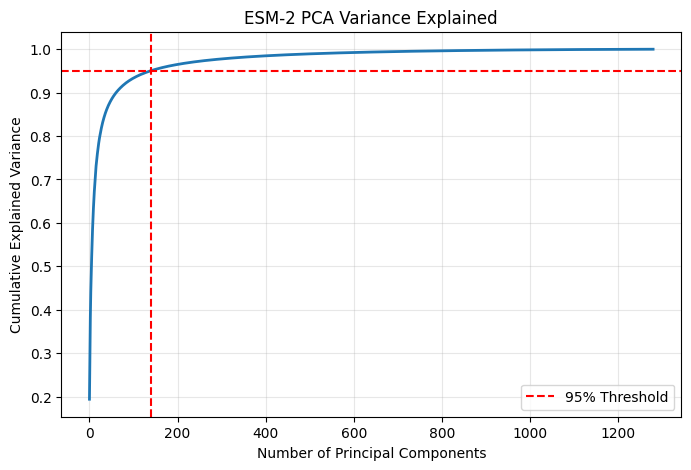

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib

# Assuming your esm_df has the peptide IDs as the index
# and the 1280 features as the columns.
esm_features = all_embeddings.values

# 1. Standardize the features (Crucial before PCA)
scaler = StandardScaler()
esm_scaled = scaler.fit_transform(esm_features)

# 2. Fit the full PCA to analyze the variance
pca_full = PCA()
pca_full.fit(esm_scaled)

# 3. Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 4. Find the exact number of components for your thresholds
k_90 = np.argmax(cumulative_variance >= 0.90) + 1
k_95 = np.argmax(cumulative_variance >= 0.95) + 1
k_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Components for 90% variance: {k_90}")
print(f"Components for 95% variance: {k_95}")
print(f"Components for 99% variance: {k_99}")

# Plotting the variance curve is always good for the final report
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.axvline(x=k_95, color='r', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('ESM-2 PCA Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:

pca_final = PCA(n_components=k_95)
esm_pca_transformed = pca_final.fit_transform(esm_scaled)

# 2. Convert back to a DataFrame to keep your peptide index intact
esm_pca_df = pd.DataFrame(
    esm_pca_transformed,
    index=all_embeddings.index,
    columns=[f"PC_{i+1}" for i in range(k_95)]
)

In [ ]:
peptides_w_data = list(set(full_mic_data['Peptide ID']) & set(all_chem_phys.index))

# TODO should relax this - no need to drop duplicates
has_data_noDup = full_mic_data[full_mic_data['Peptide ID'].isin(peptides_w_data)].drop_duplicates(['Peptide ID', 'Target Species'])
# test data (only a few species, no duplicates)
#top_species = has_data_noDup.groupby('Target Species').size().sort_values(ascending=False).iloc[:20].index
top_species_df = has_data_noDup.groupby('Target Species').size()
top_species = top_species_df[top_species_df > 200].index
test_mic = has_data_noDup[has_data_noDup['Target Species'].isin(top_species)][['Peptide ID', 'Target Species', 'Activity']].dropna()
test_mic = test_mic[test_mic["Activity"].astype(str).str.match("^[0-9.]+$", na=False)]
test_mic['mic'] = np.log2(test_mic['Activity'].astype(float))

# subtract global mean
global_mean = test_mic['mic'].mean()
test_mic['mic'] = test_mic['mic'] - global_mean

test_mic.shape

(33353, 4)

## Old Plots

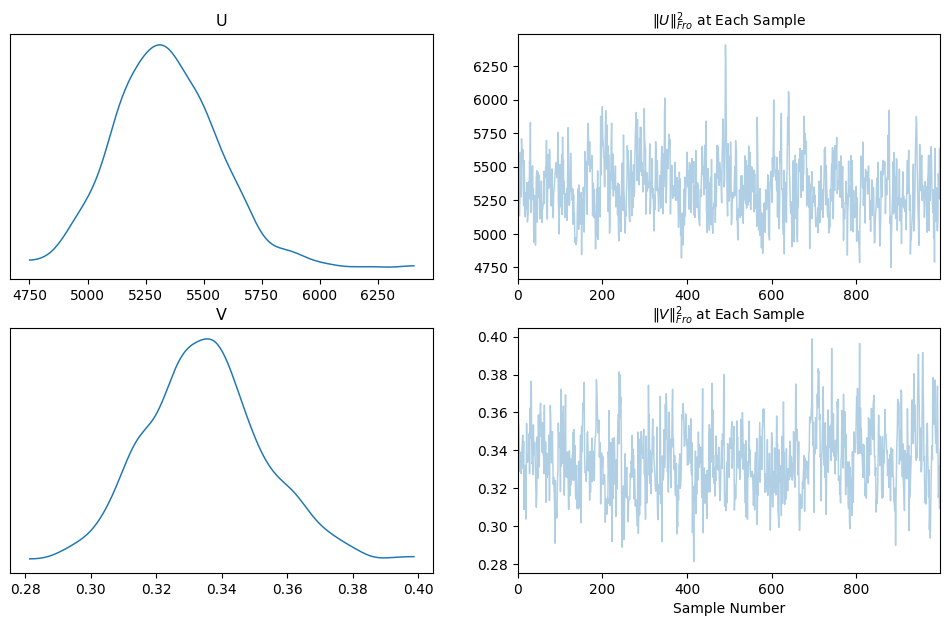

In [ ]:


# with gpu, log2(MIC), advi init, and 1000 tune samples, AND fixed correlations AND ESM PCA
hpmf_model.traceplot()

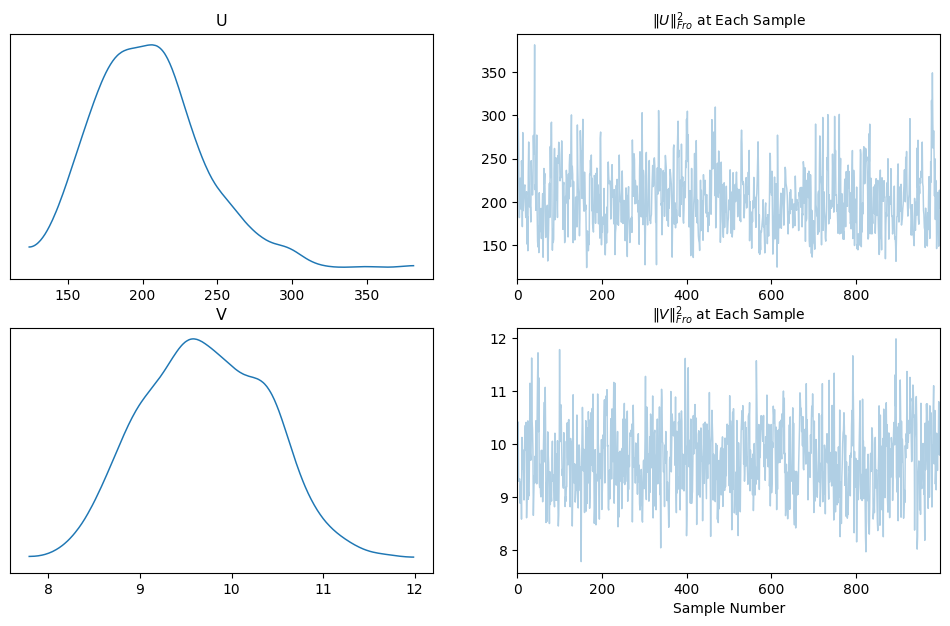

In [ ]:

# with gpu, log2(MIC), advi init, and 1000 tune samples, AND fixed correlations
hpmf_model.traceplot()

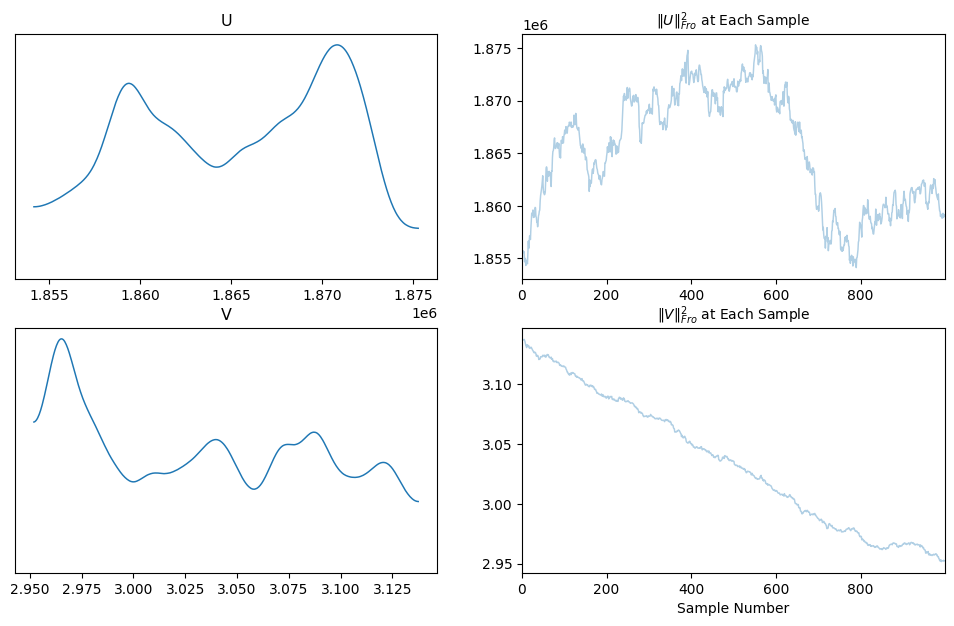

In [ ]:
# with gpu, log2(MIC), advi init, and 1000 tune samples
hpmf_model.traceplot()

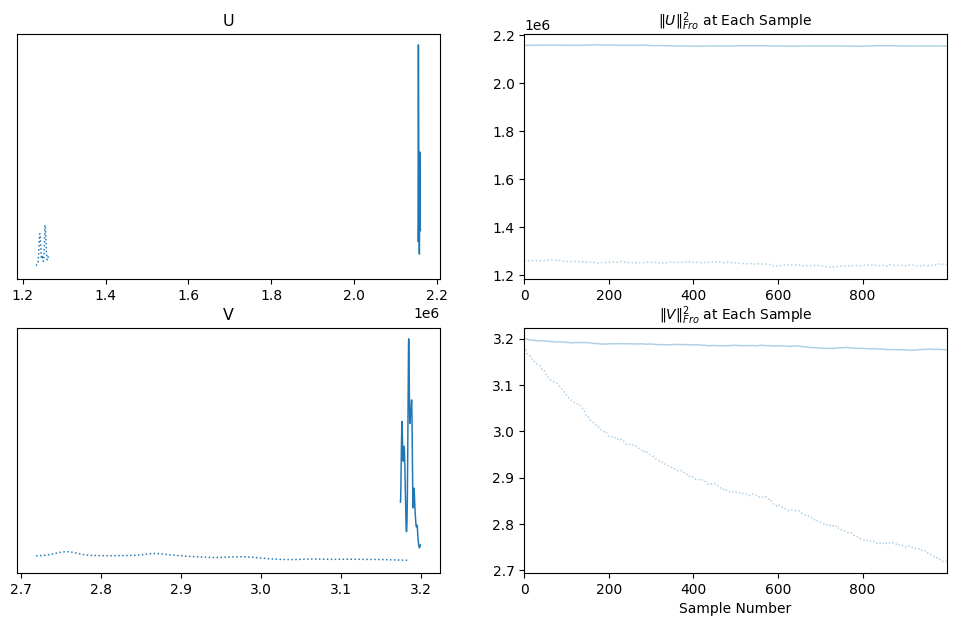

In [ ]:
hpmf_model.traceplot()

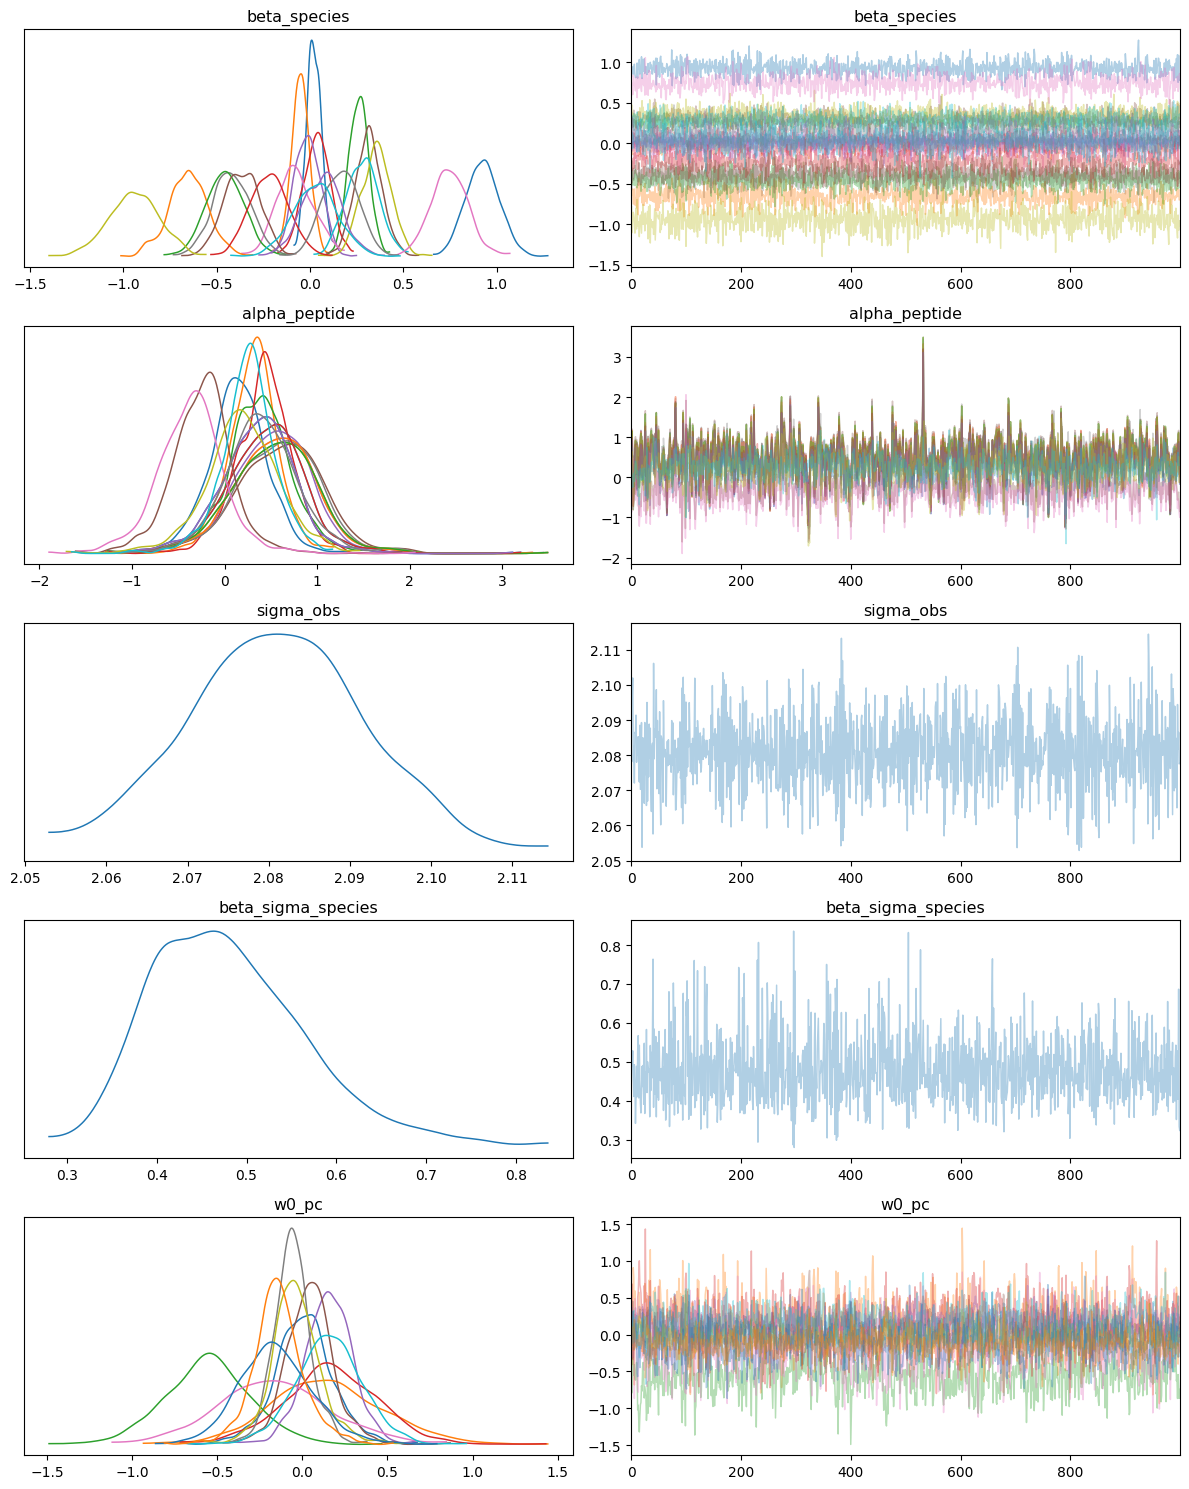

In [ ]:
idata = hpmf_model.idata
peptide_list=test_mic['Peptide ID'].unique()[:20]
species_list=top_species

# Always plot the global mean
var_names = []
coords = {}

if species_list is not None:
    var_names.append("beta_species")
    # Convert string names to the integer indices used in the model
    coords["species"] = [hpmf_model.species_dict[s] for s in species_list]

if peptide_list is not None:
    var_names.append("alpha_peptide")
    coords["peptide"] = [hpmf_model.peptide_dict[p] for p in peptide_list]

var_names.append("sigma_obs")
var_names.append("beta_sigma_species")
var_names.append("w0_pc")

# Plot using ArviZ
az.plot_trace(idata, var_names=var_names, coords=coords, figsize=(12, 3 * len(var_names)))
plt.tight_layout()
plt.show()

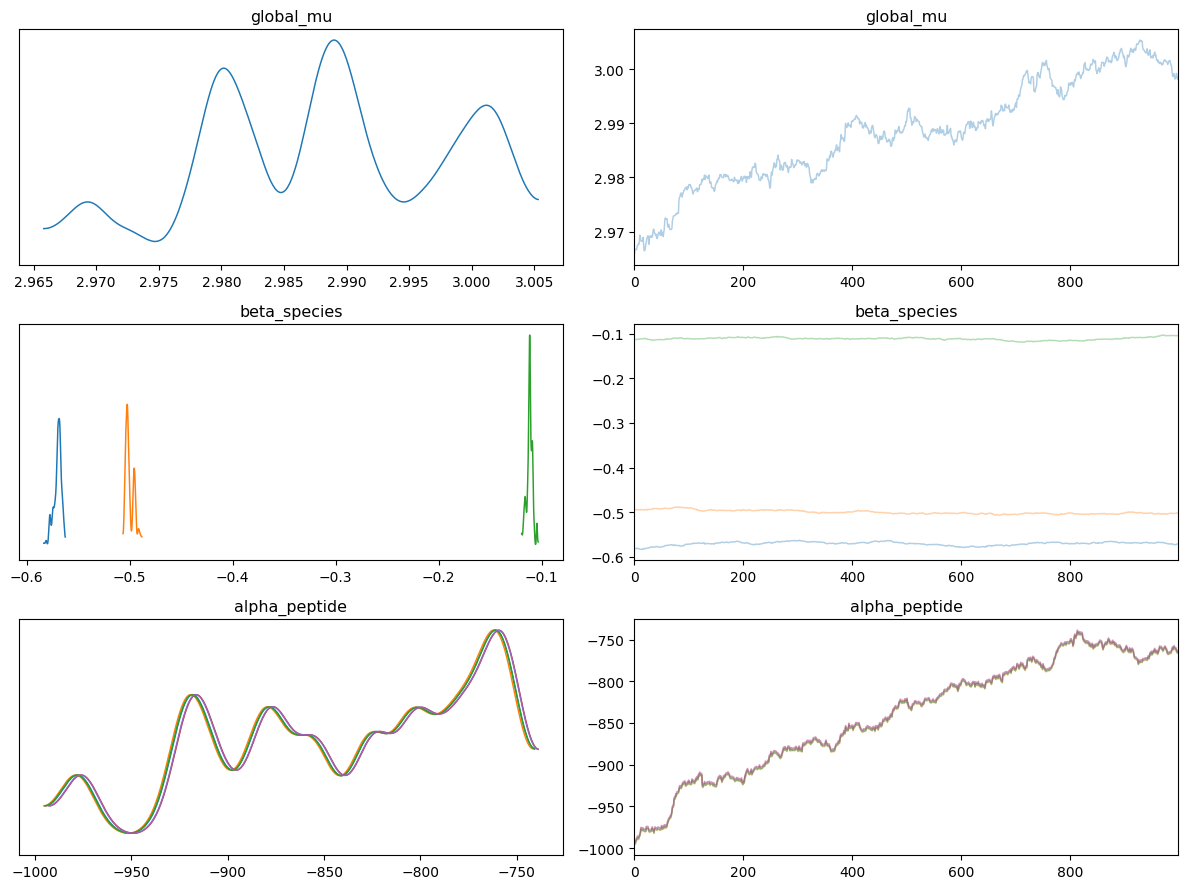

In [ ]:
# with gpu, log2(MIC), advi init, and 1000 tune samples

hpmf_model.plot_intercept_traces(
    species_list=top_species,
    peptide_list=test_mic['Peptide ID'].unique()[:5]
)

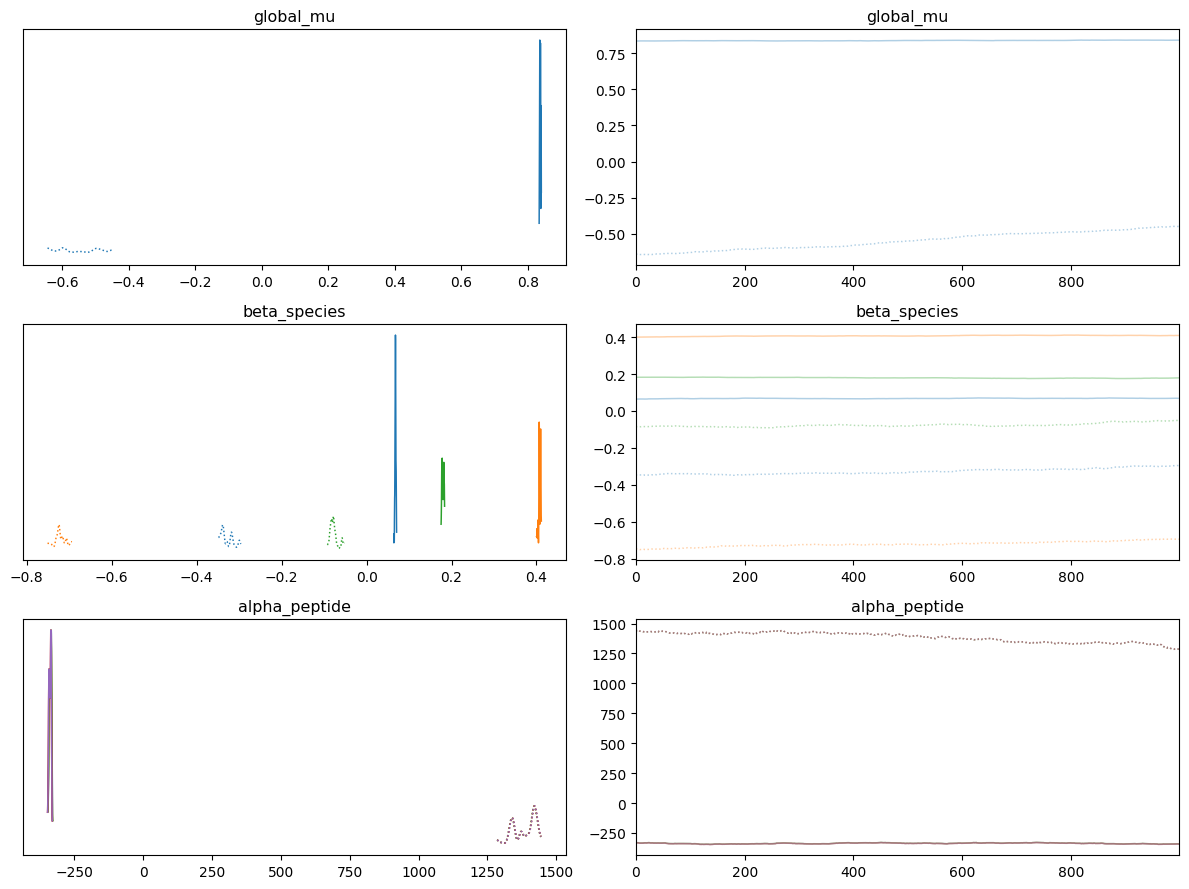

In [ ]:

hpmf_model.plot_intercept_traces(
    species_list=top_species,
    peptide_list=test_mic['Peptide ID'].unique()[:5]
)

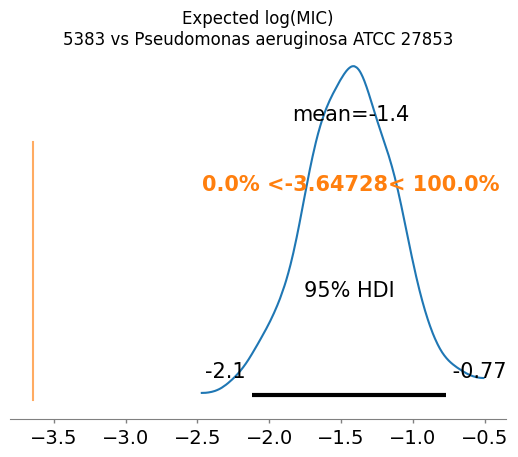

In [ ]:

idata = hpmf_model.idata
post = idata.posterior

true_mic = test_mic.iloc[1001]
peptide_id = true_mic['Peptide ID']
species_id = true_mic['Target Species']
true_mic = true_mic['mic']

# Look up the internal integer indices
try:
    p_idx = hpmf_model.peptide_dict[peptide_id]
    s_idx = hpmf_model.species_dict[species_id]
except KeyError as e:
    raise ValueError(f"ID {e} not found in the training dictionary.")

# 1. Extract the specific slices for this pair
alpha = post["alpha_peptide"].sel(peptide=p_idx)
beta = post["beta_species"].sel(species=s_idx)
u_vec = post["U"].sel(peptide=p_idx)
v_vec = post["V_species"].sel(species=s_idx)

# 2. Calculate the dot product across the latent factor dimension
# xarray automatically handles broadcasting across chains and draws
interaction = (u_vec * v_vec).sum(dim="latent_factor")

# 3. Reconstruct the expected log(MIC)
mu_posterior = alpha + beta + interaction # + post["global_mu"]

# 4. Plot using ArviZ
ax = az.plot_posterior(
    mu_posterior,
    ref_val=true_mic,
    point_estimate="mean",
    hdi_prob=0.95
)
ax.set_title(f"Expected log(MIC)\n{peptide_id} vs {species_id}")
plt.show()

In [ ]:
evaluate(hpmf_model, test_mic.iloc[:1000])

Output()


────────────────────────────────────────────────
  N        : 1000
  RMSE     : 1.8376
  Pearson  : r=0.6021  p=1.13e-99
  Spearman : r=0.6124  p=5.35e-104
────────────────────────────────────────────────



{'n': 1000,
 'rmse': np.float64(1.8376238256423676),
 'pearson_r': np.float64(0.6020883583530119),
 'pearson_p': np.float64(1.132210752315736e-99),
 'spearman_r': np.float64(0.6124439887416422),
 'spearman_p': np.float64(5.348320769771175e-104)}

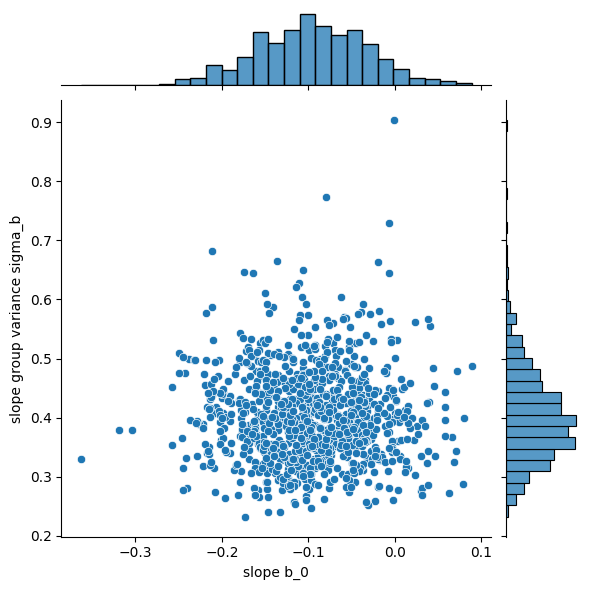

In [ ]:
# Diagnose problem with centered model?
import seaborn as sns

trace = hpmf_model.idata

x = pd.Series(trace['posterior']['beta_species'][0][:,0], name='slope b_0')
y = pd.Series(trace['posterior']['beta_sigma_species'][0], name='slope group variance sigma_b')

sns.jointplot(x=x, y=y);

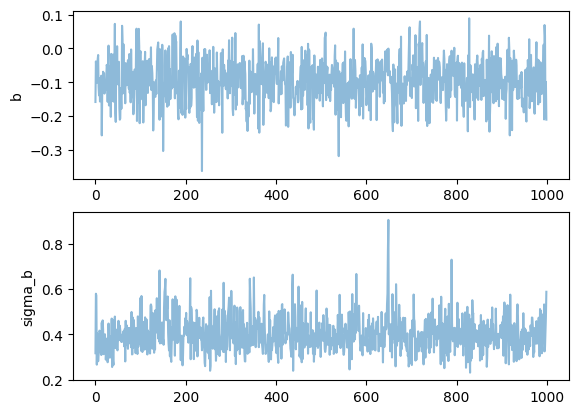

In [ ]:

fig, axs = plt.subplots(nrows=2)
axs[0].plot(trace['posterior']['beta_species'][0][:,0], alpha=.5);
axs[0].set(ylabel='b');
axs[1].plot(trace['posterior']['beta_sigma_species'][0], alpha=.5);
axs[1].set(ylabel='sigma_b');

In [ ]:
summary = az.summary(hpmf_model.idata, var_names=["alpha"], filter_vars="like")

summary

Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_peptide[0],-0.131,0.727,-1.533,1.137,0.100,0.038,52.0,147.0,NaN
alpha_peptide[1],1.227,0.611,0.139,2.307,0.083,0.046,57.0,120.0,NaN
alpha_peptide[2],1.491,0.631,0.360,2.614,0.084,0.039,58.0,169.0,NaN
alpha_peptide[3],1.735,0.582,0.595,2.707,0.070,0.033,69.0,161.0,NaN
alpha_peptide[4],0.151,0.482,-0.740,1.032,0.056,0.025,72.0,198.0,NaN
...,...,...,...,...,...,...,...,...,...
alpha_peptide[8298],-0.426,0.522,-1.357,0.536,0.069,0.050,57.0,152.0,NaN
alpha_peptide[8299],-0.562,0.575,-1.636,0.438,0.077,0.079,56.0,137.0,NaN
alpha_peptide[8300],-0.167,0.422,-0.890,0.687,0.051,0.028,69.0,106.0,NaN
alpha_peptide[8301],-0.637,1.028,-2.821,1.102,0.103,0.045,99.0,253.0,NaN


## Training Run

In [ ]:
top_20_species = test_mic.copy()
phys_chem_norm = pc_normalized.iloc[:, 1:-3].copy()
esm_pca_input = esm_pca_df.copy()

train_df, hold_peptides_test = split_holdout_peptides(top_20_species, holdout_frac=0.10, random_state=42)
train_df, random_test = split_random_mask(train_df, holdout_frac=0.20, random_state=42)

[peptide holdout]  train peptides=9360  test peptides=1039  (3307 obs)
[random mask]  train obs=24037  test obs=6009


In [ ]:
hpmf_test_wESM = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                        None, dim=10, include_esm=True, horseshoe=False)
with hpmf_test_wESM.model:
    # This evaluates the log-probability of every parameter at its starting value
    print(hpmf_test_wESM.model.point_logps())

{'B_pc': np.float64(-110.27), 'B_esm': np.float64(-1277.32), 'V_species': np.float64(-661.64), 'beta_sigma_species': np.float64(-0.73), 'beta_species': np.float64(-65.24), 'w0_pc': np.float64(-11.03), 'w0_esm': np.float64(192.33), 'sigma_obs': np.float64(-0.73), 'MIC_obs': np.float64(-84807.73)}


In [ ]:
hpmf_model_wESM = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                        None, dim=10, include_esm=True, horseshoe=False)

hpmf_model_wESM.draw_samples(draws=1500, tune=2000, init="advi+adapt_diag", nuts_sampler="numpyro", n_init=50000)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 3500/3500 [52:37<00:00,  1.11it/s, 1023 steps of size 2.20e-02. acc. prob=0.88]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[2,1500,71].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [ ]:
hpmf_model_wESM.idata.to_netcdf("/content/drive/MyDrive/STATS305c/ecm_model.nc")

In [ ]:
hpmf_model_wESM_idata = az.from_netcdf(os.path.join(file_path, "ecm_model.nc"))

In [ ]:
hpmf_model_wESM = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                        None, dim=10, include_esm=True, horseshoe=False)
hpmf_model_wESM.idata = hpmf_model_wESM_idata

In [ ]:

hpmf_model_wESM.evaluate(train_df)
hpmf_model_wESM.evaluate(random_test)
hpmf_model_wESM.evaluate(hold_peptides_test)


Output()


────────────────────────────────────────────────
  N        : 24037
  RMSE     : 1.6433
  Pearson  : r=0.6975  p=0
  Spearman : r=0.6666  p=0
────────────────────────────────────────────────



Output()

Output()


────────────────────────────────────────────────
  N        : 6009
  RMSE     : 1.8767
  Pearson  : r=0.5825  p=0
  Spearman : r=0.5496  p=0
────────────────────────────────────────────────




────────────────────────────────────────────────
  N        : 3307
  RMSE     : 1.9253
  Pearson  : r=0.5568  p=1.22e-268
  Spearman : r=0.5125  p=5.15e-221
────────────────────────────────────────────────



{'n': 3307,
 'rmse': np.float64(1.9253122713429163),
 'pearson_r': np.float64(0.5567831711183301),
 'pearson_p': np.float64(1.2208591668753573e-268),
 'spearman_r': np.float64(0.512545408591133),
 'spearman_p': np.float64(5.147500713969962e-221)}


wESM_PCA — posterior summary
                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
sigma_obs         1.734  0.009   1.717    1.749      0.000    0.000    3136.0   
B_pc[0, 0]        0.005  1.092  -2.145    1.873      0.035    0.016    1002.0   
B_pc[0, 1]       -0.017  1.081  -1.998    1.978      0.035    0.015     964.0   
B_pc[0, 2]       -0.006  1.095  -2.012    2.009      0.036    0.017     945.0   
B_pc[0, 3]       -0.013  1.090  -2.101    1.920      0.035    0.018     945.0   
...                 ...    ...     ...      ...        ...      ...       ...   
V_species[71, 5]  0.004  0.521  -1.022    0.947      0.010    0.010    2577.0   
V_species[71, 6] -0.003  0.519  -1.013    0.966      0.010    0.009    2567.0   
V_species[71, 7] -0.004  0.534  -1.062    0.944      0.011    0.011    2543.0   
V_species[71, 8]  0.013  0.530  -1.044    1.001      0.010    0.010    2617.0   
V_species[71, 9]  0.002  0.529  -0.992    1.078      0.011    0.009    2253.0  

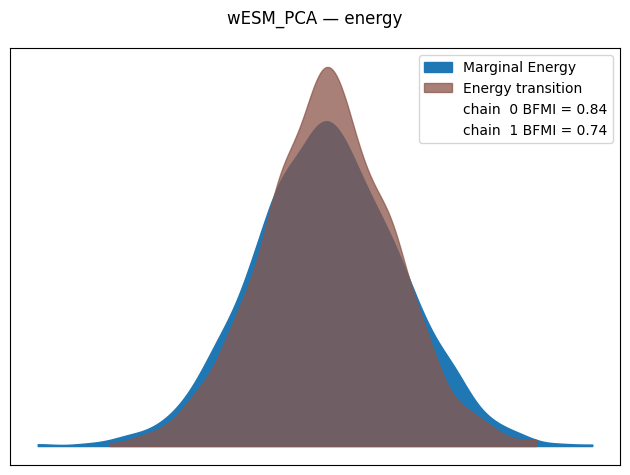

In [ ]:
diagnose_mcmc(hpmf_model_wESM.idata, label="wESM_PCA")

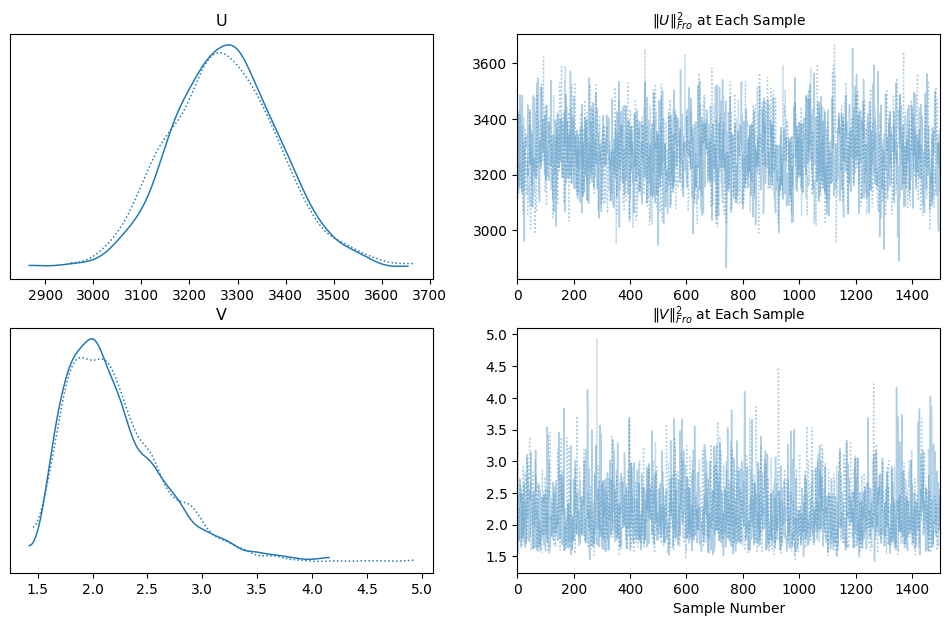

In [ ]:

hpmf_model_wESM.traceplot()

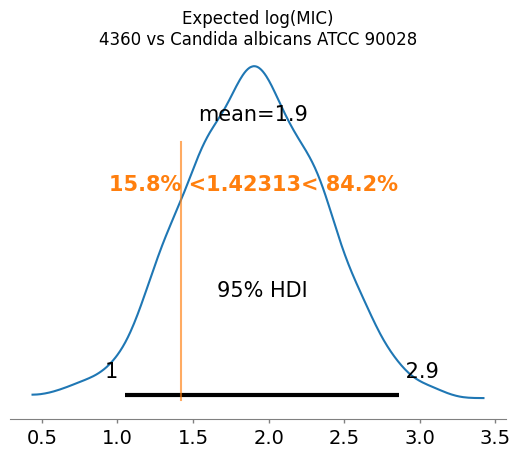

In [48]:
true_mic = train_df.iloc[14]
peptide_id = true_mic['Peptide ID']
species_id = true_mic['Target Species']
true_mic = true_mic['mic']

hpmf_model_wESM.plot_mic_posterior(peptide_id, species_id, true_mic=true_mic)

plt.savefig(os.path.join(file_path, "random_posterior_y.png"), bbox_inches="tight")

AttributeError: 'str' object has no attribute 'size'

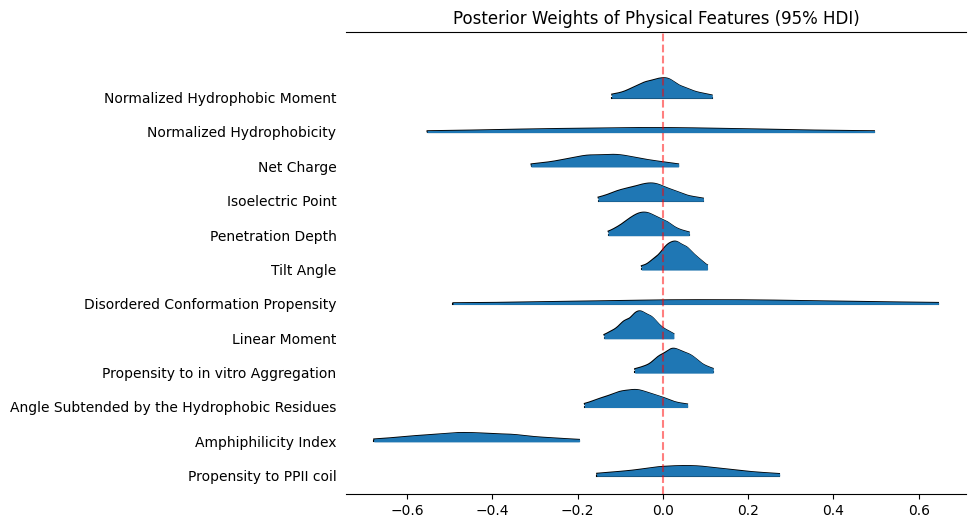

In [ ]:

hpmf_model_wESM.plot_feature_weights(kind="ridgeplot")
plt.savefig(os.path.join(file_path, "hpmf_model_wESM.w0_pc.ridgeplot.png"), bbox_inches="tight_layout")

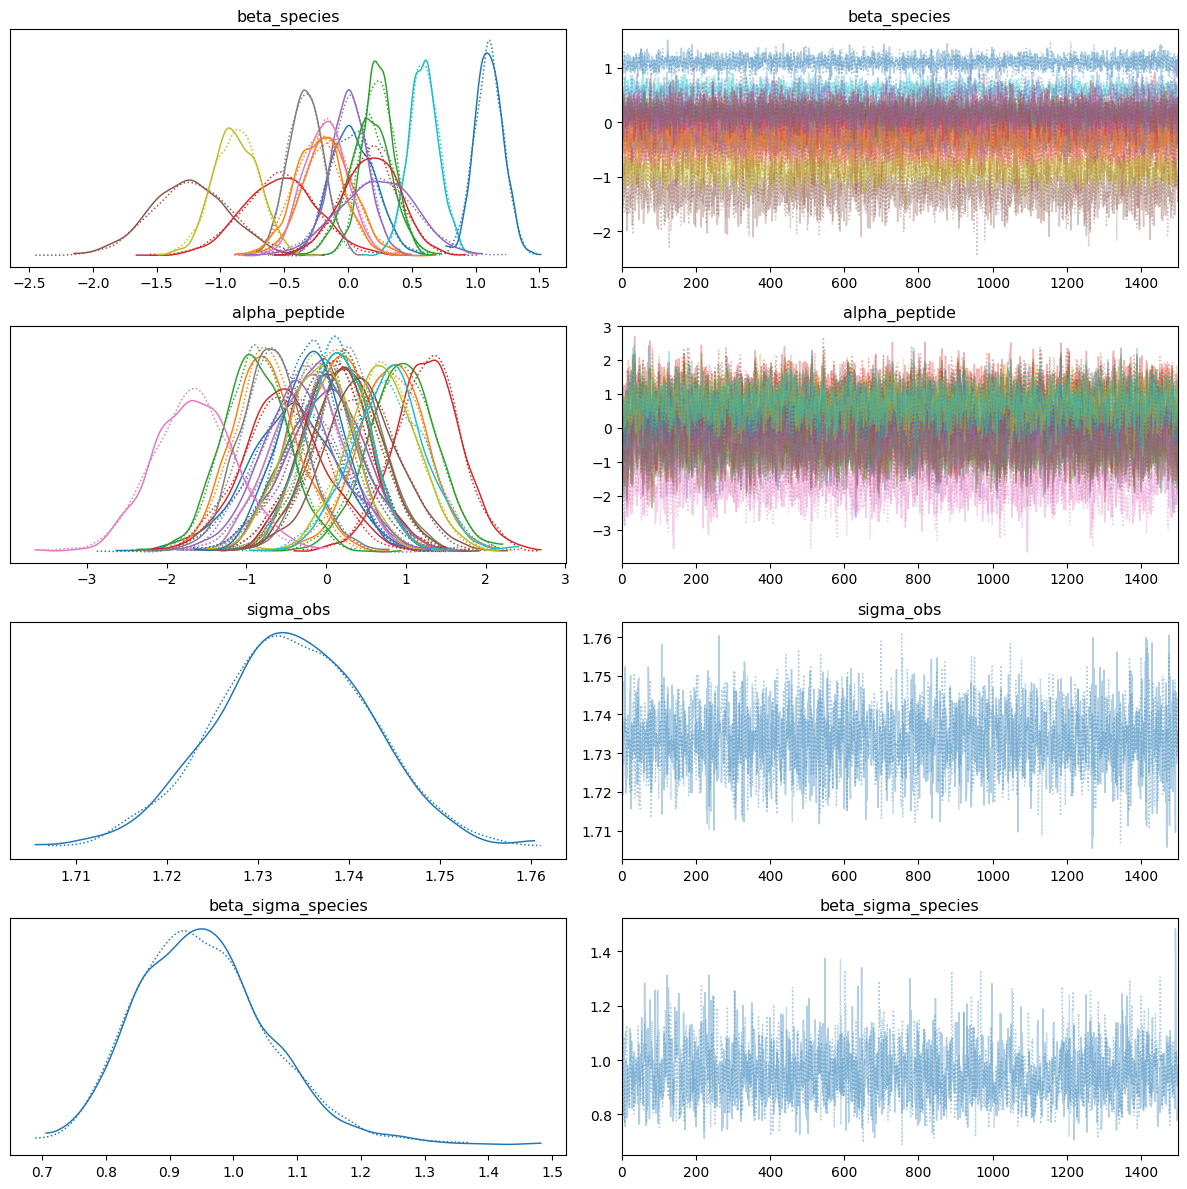

In [ ]:

hpmf_model_wESM.plot_intercept_traces(
    species_list=top_species[:15],
    peptide_list=train_df['Peptide ID'].unique()[:30]
)

In [ ]:

hpmf_model_wESM.plot_mic_posterior(test_mic['Peptide ID'].unique()[0], top_species[0], true_mic=3.5)

In [ ]:
hpmf_lin_model_wESM = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                        None, dim=10, include_esm=True, horseshoe=False, linreg=True)

hpmf_lin_model_wESM.draw_samples(draws=1500, tune=2000, init="advi+adapt_diag", nuts_sampler="numpyro", n_init=50000)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 3500/3500 [04:19<00:00, 13.51it/s, 127 steps of size 3.39e-02. acc. prob=0.94]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[2,1500,71].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [ ]:
hpmf_lin_model_wESM.idata.to_netcdf("/content/drive/MyDrive/STATS305c/linear_ecm_model.nc")

'/content/drive/MyDrive/STATS305c/linear_ecm_model.nc'

In [ ]:

import scipy.stats as stats

hpmf_lin_model_wESM.evaluate(train_df)
hpmf_lin_model_wESM.evaluate(random_test)
hpmf_lin_model_wESM.evaluate(hold_peptides_test)


Output()

Output()


────────────────────────────────────────────────
  N        : 24037
  RMSE     : 1.9871
  Pearson  : r=0.4940  p=0
  Spearman : r=0.4712  p=0
────────────────────────────────────────────────



Output()


────────────────────────────────────────────────
  N        : 6009
  RMSE     : 2.0208
  Pearson  : r=0.4804  p=0
  Spearman : r=0.4507  p=1.45e-298
────────────────────────────────────────────────




────────────────────────────────────────────────
  N        : 3307
  RMSE     : 2.0593
  Pearson  : r=0.4515  p=7.73e-166
  Spearman : r=0.4218  p=7.85e-143
────────────────────────────────────────────────



{'n': 3307,
 'rmse': np.float64(2.0592919321989016),
 'pearson_r': np.float64(0.4514887877316934),
 'pearson_p': np.float64(7.732727672930237e-166),
 'spearman_r': np.float64(0.4218289135650451),
 'spearman_p': np.float64(7.851685246800204e-143)}

In [ ]:

hpmf_model = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                        None, dim=10, include_esm=False, horseshoe=False)

hpmf_model.draw_samples(draws=1000, tune=1000, init="advi+adapt_diag", nuts_sampler="numpyro", n_init=50000)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 2000/2000 [11:49<00:00,  2.82it/s, 511 steps of size 1.39e-02. acc. prob=0.90]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[2,1000,19].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [ ]:

hpmf_model.evaluate(train_df)
hpmf_model.evaluate(random_test)
hpmf_model.evaluate(hold_peptides_test)

Output()

Output()


────────────────────────────────────────────────
  N        : 15437
  RMSE     : 2.0586
  Pearson  : r=0.3764  p=0
  Spearman : r=0.3589  p=0
────────────────────────────────────────────────



Output()


────────────────────────────────────────────────
  N        : 3859
  RMSE     : 2.1314
  Pearson  : r=0.3340  p=3.51e-101
  Spearman : r=0.3208  p=4.6e-93
────────────────────────────────────────────────




────────────────────────────────────────────────
  N        : 2114
  RMSE     : 2.0978
  Pearson  : r=0.2927  p=4.78e-43
  Spearman : r=0.2941  p=1.92e-43
────────────────────────────────────────────────



{'n': 2114,
 'rmse': np.float64(2.0977810541765636),
 'pearson_r': np.float64(0.2927494849815559),
 'pearson_p': np.float64(4.780076182686892e-43),
 'spearman_r': np.float64(0.2940890532030397),
 'spearman_p': np.float64(1.9186160234200893e-43)}


noESM — posterior summary
                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
sigma_obs         2.074  0.012   2.053    2.096      0.000    0.000    3132.0   
B_pc[0, 0]        0.001  0.299  -0.574    0.567      0.010    0.006     980.0   
B_pc[0, 1]       -0.008  0.297  -0.563    0.562      0.009    0.008    1085.0   
B_pc[0, 2]        0.008  0.294  -0.550    0.543      0.009    0.006    1093.0   
B_pc[0, 3]        0.003  0.302  -0.535    0.567      0.009    0.007    1060.0   
...                 ...    ...     ...      ...        ...      ...       ...   
V_species[19, 5]  0.035  0.696  -1.411    1.232      0.017    0.013    1641.0   
V_species[19, 6]  0.002  0.691  -1.173    1.341      0.016    0.012    1822.0   
V_species[19, 7]  0.001  0.691  -1.330    1.221      0.018    0.013    1483.0   
V_species[19, 8]  0.034  0.686  -1.310    1.282      0.017    0.011    1597.0   
V_species[19, 9]  0.013  0.713  -1.325    1.397      0.017    0.013    1735.0   



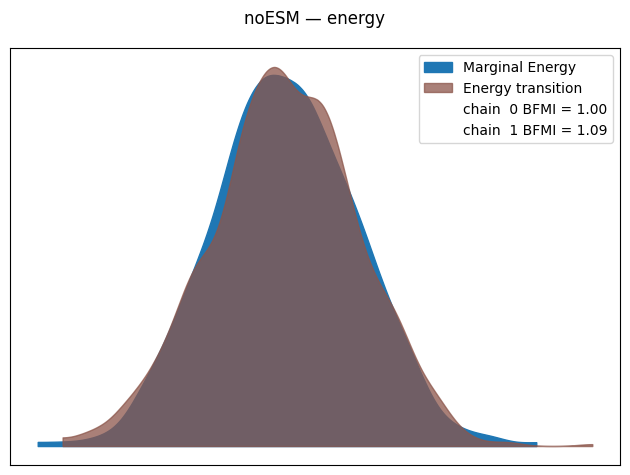

In [ ]:
diagnose_mcmc(hpmf_model.idata, label="noESM")

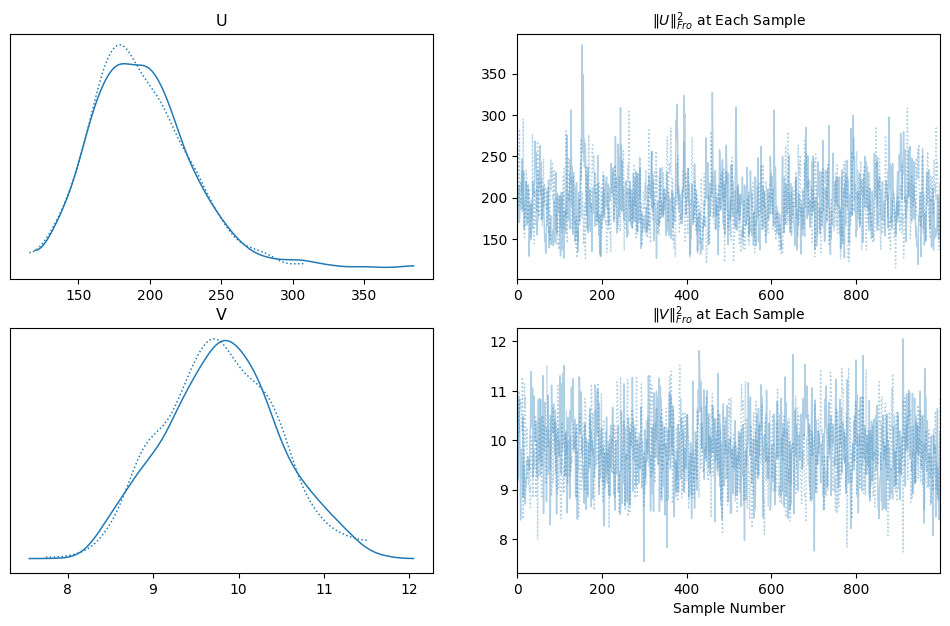

In [ ]:

hpmf_model.traceplot()

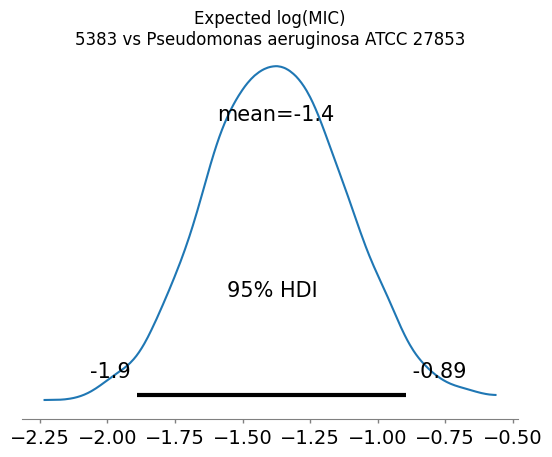

<xarray.DataArray 'x' (chain: 2, draw: 1000)> Size: 16kB
array([[-1.30295692, -1.4414812 , -1.49895397, ..., -1.14130987,
        -1.77138417, -1.22066635],
       [-1.37492425, -1.87994185, -1.2802368 , ..., -1.48210621,
        -1.34100866, -1.47667121]])
Coordinates:
  * chain    (chain) int64 16B 0 1
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
    peptide  int64 8B 341
    species  int64 8B 3

In [ ]:

hpmf_model.plot_mic_posterior(peptide_id, species_id, true_mic=None)

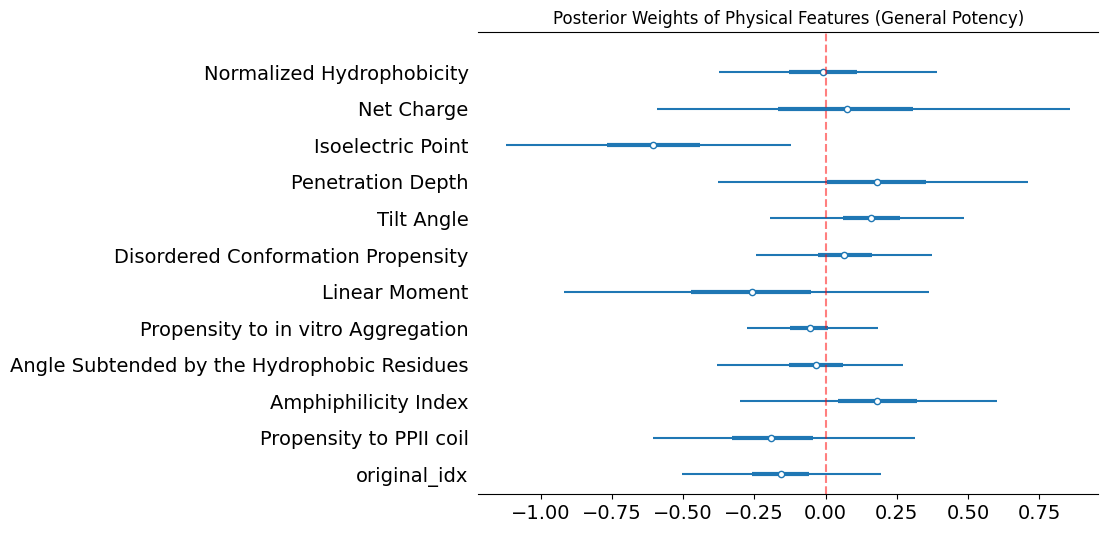

In [ ]:
# TODO check column names - missing one?
hpmf_model.plot_feature_weights()

In [ ]:

hpmf_model.plot_intercept_traces(
    species_list=top_species,
    peptide_list=test_mic['Peptide ID'].unique()[:5]
)

KeyError: np.int64(4359)

In [ ]:
#Testing VI cs MCMC
#Need to debug

def train_model(long_df, all_chem_phys, all_embeddings, method="mcmc", **kwargs):
    """
    method: "mcmc" uses draw_samples (pm.sample)
            "vi"   uses var_inference (pm.fit)
    kwargs: passed directly to draw_samples or var_inference
            e.g. draws=300, tune=100 for mcmc
                 n=10000 for vi
    """
    # deduplicate to unique peptides before passing in
    unique_peps = long_df["Peptide ID"].unique()

    model = Hybrid_PMF(
        long_df.copy(),
        all_chem_phys.iloc[:, 1:-3].copy(),
        all_embeddings.copy(),
        None, dim=10, include_esm=False,
    )

    if method == "mcmc":
        idata = model.draw_samples(**kwargs)
    elif method == "vi":
        approx = model.var_inference(**kwargs)
        idata  = approx.sample(2000)   # draw samples from the VI approximation

    return model, idata


# ── Usage ─────────────────────────────────────────────────

# split (same split for fair comparison)
train_df, test_df = split_random_mask(test_mic, holdout_frac=0.20)

# MCMC
model_mcmc, idata_mcmc = train_model(train_df, all_chem_phys, all_embeddings,
                                     method="mcmc", draws=300, tune=100)

# VI
model_vi, idata_vi = train_model(train_df, all_chem_phys, all_embeddings,
                                 method="vi", n=10000)


Fitting: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 100% 0:00:01 Average Loss = 4.2247e+09

In [ ]:
def diagnose_mcmc(idata, label=""):

    # ── 1. R-hat and ESS ──────────────────────────────────
    summary = az.summary(idata, var_names=["sigma_obs", "B_pc", "V_species"])  # "global_mu"
    print(f"\n{label} — posterior summary")
    print(summary)

    bad_rhat = summary[summary["r_hat"] > 1.01]
    low_ess  = summary[summary["ess_bulk"] < 400]
    if len(bad_rhat):
        print(f"\nWARNING: {len(bad_rhat)} parameters with r_hat > 1.01")
    if len(low_ess):
        print(f"WARNING: {len(low_ess)} parameters with ESS < 400")
    else:
        print("\nMCMC looks healthy")

    # ── 2. Trace plots ────────────────────────────────────
    # az.plot_trace(idata, var_names=["global_mu", "sigma_obs"])
    # plt.suptitle(f"{label} — trace plots")
    # plt.tight_layout()
    # plt.show()

    # ── 3. Energy plot ────────────────────────────────────
    az.plot_energy(idata)
    plt.suptitle(f"{label} — energy")
    plt.tight_layout()
    plt.show()


Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)



MCMC — posterior summary
                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
sigma_obs         1.831  0.009   1.814    1.847      0.000    0.000    1015.0   
B_pc[0, 0]       -0.183  1.088  -2.225    1.738      0.147    0.038      56.0   
B_pc[0, 1]       -0.208  1.107  -2.414    1.641      0.157    0.042      50.0   
B_pc[0, 2]        0.122  1.097  -1.993    2.128      0.125    0.041      77.0   
B_pc[0, 3]        0.137  1.072  -1.807    2.217      0.172    0.067      34.0   
...                 ...    ...     ...      ...        ...      ...       ...   
V_species[19, 5] -0.009  0.028  -0.060    0.041      0.006    0.002      22.0   
V_species[19, 6]  0.004  0.029  -0.051    0.054      0.005    0.002      34.0   
V_species[19, 7] -0.009  0.032  -0.066    0.055      0.006    0.003      28.0   
V_species[19, 8] -0.010  0.031  -0.063    0.050      0.005    0.002      43.0   
V_species[19, 9]  0.005  0.032  -0.053    0.063      0.005    0.003      38.0   

 

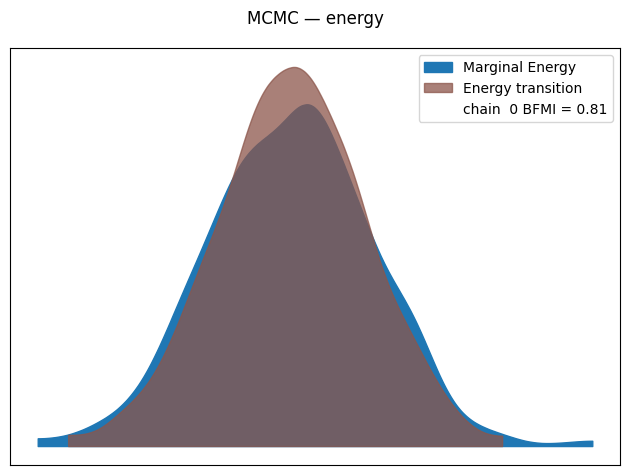

In [ ]:

# usage
diagnose_mcmc(hpmf_model.idata, label="MCMC")

In [ ]:
#Testing only on the train

# ── Strategy 1: random mask ────────────────────────────────
train_df, test_df = split_random_mask(test_mic, holdout_frac=0.20)

hpmf_model = Hybrid_PMF(train_df.copy(), all_chem_phys.iloc[:, 1:-3].copy(), all_embeddings.copy(),
                        None, dim=10, include_esm=False)
hpmf_model.draw_samples(draws=300, tune=100)

diagnose_mcmc(hpmf_model.idata, label="Strategy 1: random mask")
metrics_mask = evaluate(hpmf_model, hpmf_model.idata, test_df, all_chem_phys, all_embeddings,
                        label="Strategy 1: random mask (interpolation)")

# ── Strategy 2: held-out peptides ─────────────────────────
train_df, test_df = split_holdout_peptides(test_mic, holdout_frac=0.20)

hpmf_model = Hybrid_PMF(train_df.copy(), all_chem_phys.iloc[:, 1:-3].copy(), all_embeddings.copy(),
                        None, dim=10, include_esm=False)
hpmf_model.draw_samples(draws=300, tune=100)

diagnose_mcmc(hpmf_model.idata, label="Strategy 2: held-out peptides")
metrics_holdout = evaluate(hpmf_model, hpmf_model.idata, test_df, all_chem_phys, all_embeddings,
                           label="Strategy 2: held-out peptides (generalization)")

In [ ]:
# ── Full dataset (all species) ─────────────────────────────
peptides_w_data = list(set(full_mic_data['Peptide ID']) & set(all_chem_phys.index))
has_data_noDup  = full_mic_data[full_mic_data['Peptide ID'].isin(peptides_w_data)].drop_duplicates(['Peptide ID', 'Target Species'])
full_mic        = has_data_noDup[['Peptide ID', 'Target Species', 'Activity']].dropna()
full_mic        = full_mic[full_mic["Activity"].astype(str).str.match("^[0-9.]+$", na=False)]
full_mic['mic'] = full_mic['Activity'].astype(float)

# ── Strategy 1: random mask ────────────────────────────────
train_df, test_df = split_random_mask(full_mic, holdout_frac=0.20)

hpmf_model = Hybrid_PMF(train_df.copy(), all_chem_phys.iloc[:, 1:-3].copy(), all_embeddings.copy(),
                        None, dim=10, include_esm=False)
approx = hpmf_model.var_inference(n=10000)
hpmf_model.idata = approx.sample(2000)

metrics_mask = evaluate(hpmf_model, hpmf_model.idata, test_df, all_chem_phys, all_embeddings,
                        label="Strategy 1: random mask (interpolation)")

# ── Strategy 2: held-out peptides ─────────────────────────
train_df, test_df = split_holdout_peptides(full_mic, holdout_frac=0.20)

hpmf_model = Hybrid_PMF(train_df.copy(), all_chem_phys.iloc[:, 1:-3].copy(), all_embeddings.copy(),
                        None, dim=10, include_esm=False)
approx = hpmf_model.var_inference(n=10000)
hpmf_model.idata = approx.sample(2000)

metrics_holdout = evaluate(hpmf_model, hpmf_model.idata, test_df, all_chem_phys, all_embeddings,
                           label="Strategy 2: held-out peptides (generalization)")

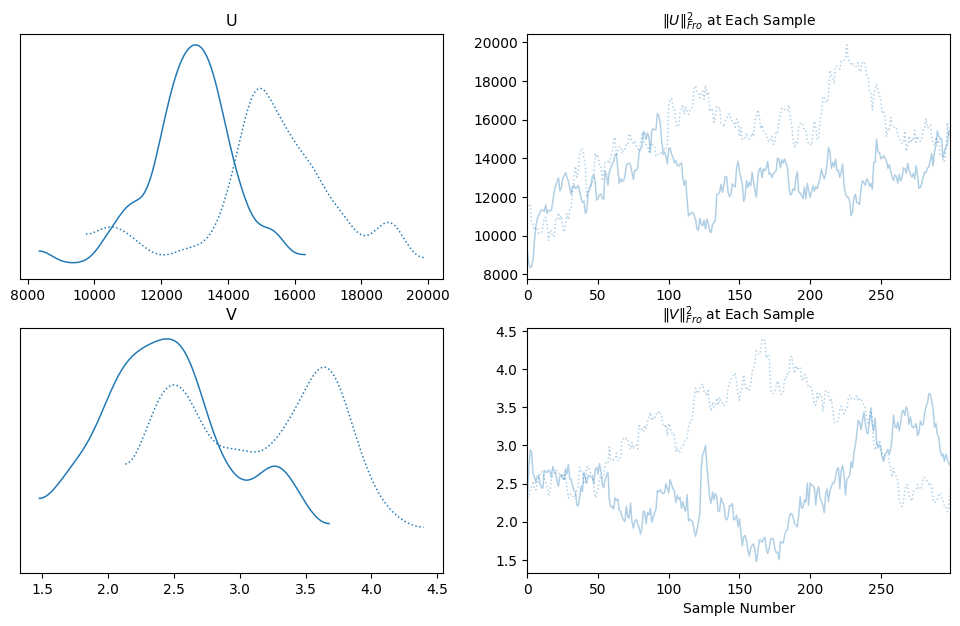

In [ ]:
_traceplot(hpmf_model)

# VI

In [ ]:
with model.model as model:
  approx = pm.fit()

Output()

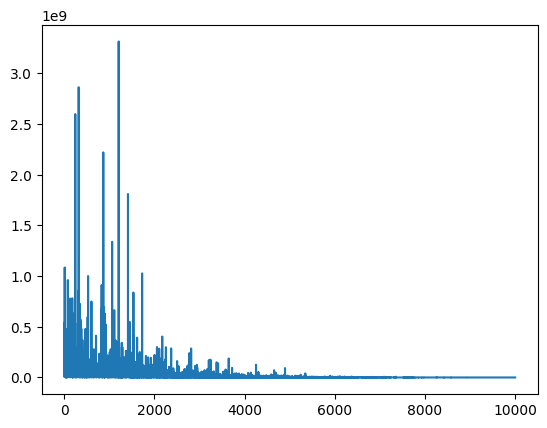

In [ ]:

plt.plot(approx.hist)

In [ ]:
import arviz as az

with model as model:
    idata = approx.sample(1000)

In [ ]:

az.summary(idata, kind="stats")


,mean,sd,hdi_3%,hdi_97%
"B_esm[0, 0]",0.013,1.014,-1.546,1.949
"B_esm[0, 1]",-0.059,0.986,-1.416,1.427
"B_esm[0, 2]",-0.031,0.948,-1.680,1.875
"B_esm[0, 3]",-0.011,1.039,-1.824,1.488
"B_esm[0, 4]",0.050,0.863,-1.356,1.648
...,...,...,...,...
w0_pc[7],-0.000,0.673,-1.119,1.446
w0_pc[8],-0.006,0.207,-0.391,0.380
w0_pc[9],0.007,0.260,-0.458,0.490
w0_pc[10],0.025,0.674,-1.256,1.236


/usr/local/lib/python3.12/dist-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


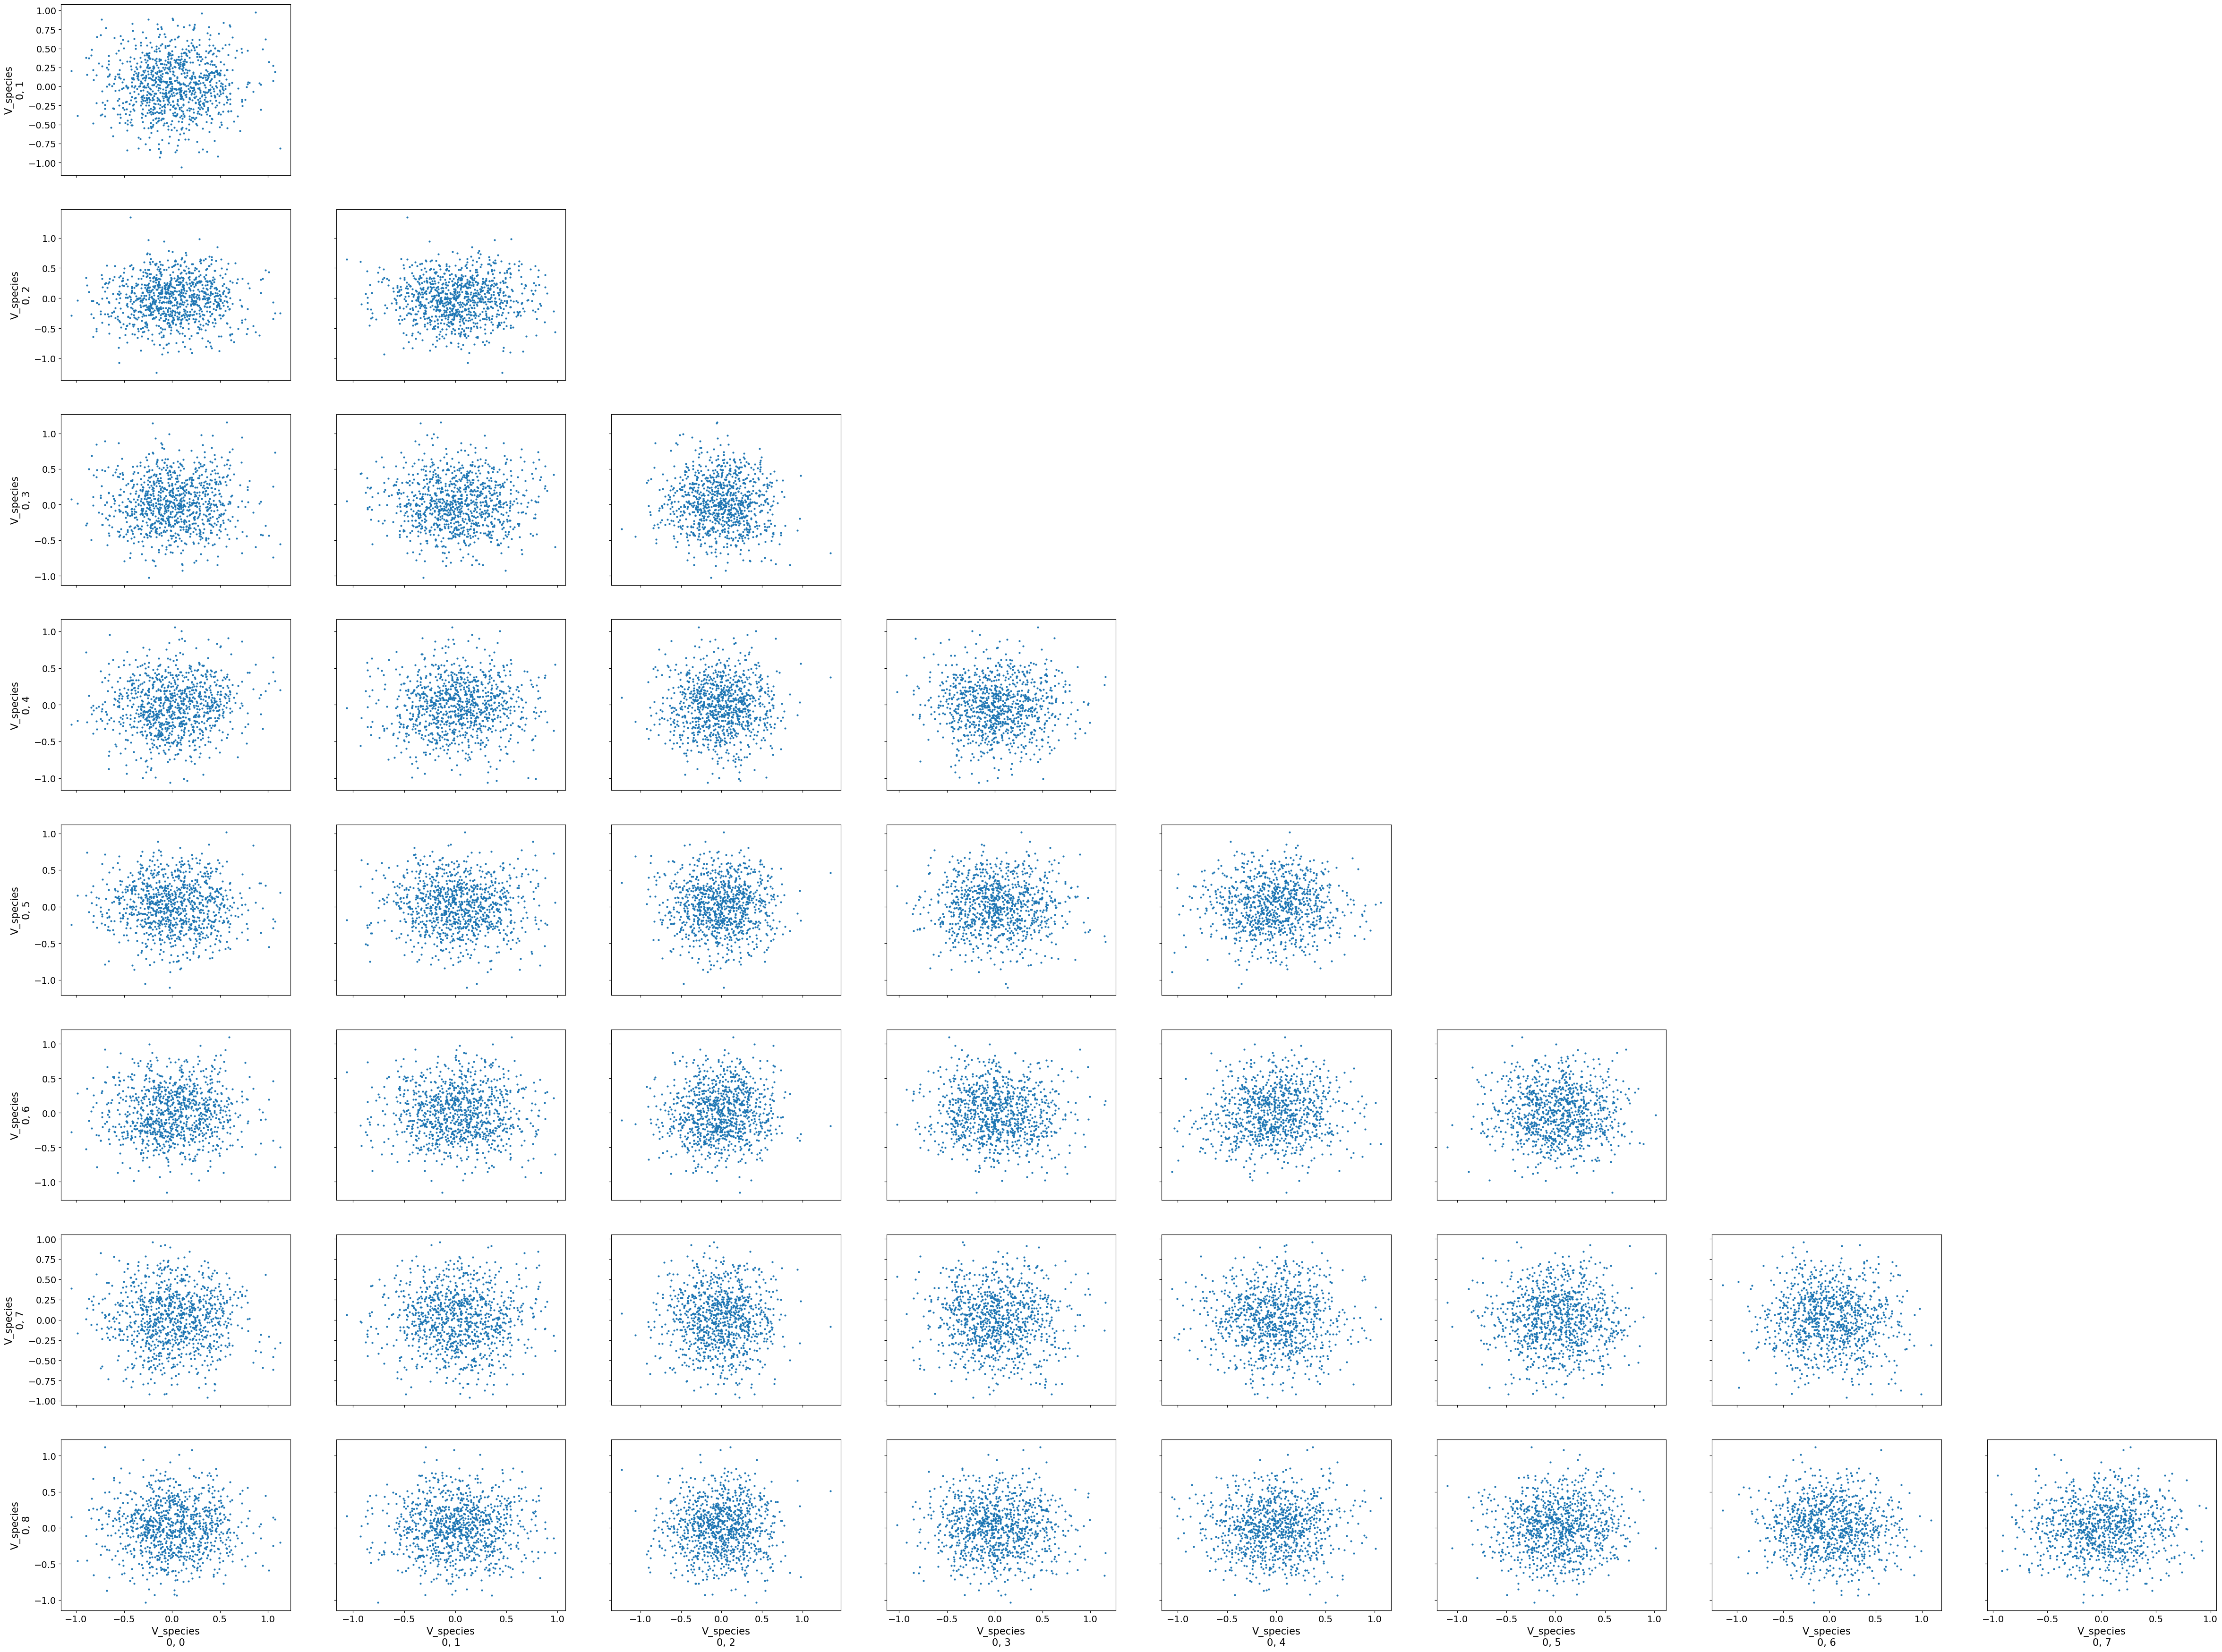

In [ ]:

az.plot_pair(idata, var_names="V_species", coords={"species": [0, 2]});

In [ ]:

hpmf_model.species_dict

{'Escherichia coli ATCC 25922': 0,
 'Staphylococcus aureus ATCC 25923': 1,
 'Pseudomonas aeruginosa ATCC 27853': 2}

In [ ]:

tmp_predict = test_mic.iloc[1:4].copy()

In [ ]:

all_chem_phys.loc[tmp_predict['Peptide ID']].iloc[:, 1:13].values

array([[  0.96,  -0.41,   3.  ,  10.7 ,  16.  ,  90.  ,   0.29,   0.19,
          3.02, 100.  ,   0.65,   0.87],
       [  0.98,  -0.43,   3.  ,  10.7 ,  23.  ,  44.  ,   0.3 ,   0.19,
          3.02, 100.  ,   0.65,   0.89],
       [  0.98,  -0.43,   3.  ,  10.7 ,  23.  ,  44.  ,   0.3 ,   0.19,
          3.02, 100.  ,   0.65,   0.89]])

In [ ]:

with hpmf_model.model:
    # change the value and shape of the data
    pm.set_data(
        {
            "pep_idx": [1000, 1001, 1002],
            # use dummy values with the same shape:
            "spec_idx": tmp_predict['Target Species'].map(hpmf_model.species_dict),
            "mic": [False, False, False],
            "X_pc": all_chem_phys.loc[tmp_predict['Peptide ID']].iloc[:, 1:13].values,
            "X_esm": all_embeddings.loc[tmp_predict['Peptide ID']].values,
        },
        coords={"idx": [1001, 1002, 1003]},
    )

    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

ValueError: The 'pep_idx' variable already had 893 coord values defined for its obs_id dimension. With the new values this dimension changes to length 3, so new coord values for the obs_id dimension are required.

In [ ]:

tmp_predict['Activity']

In [ ]:
idata.posterior_predictive["obs"].mean(dim=["draw", "chain"])

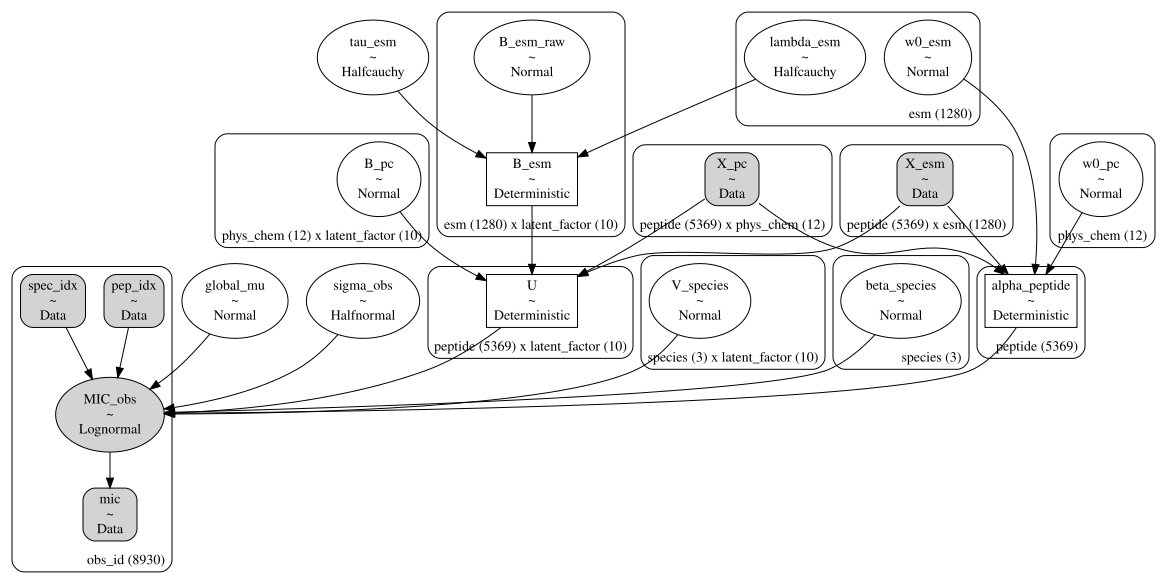

In [ ]:

pm.model_to_graphviz(model.model)

In [ ]:
#Vi vs MCMC comparison defunct bc VI takes so long

import arviz as az
import matplotlib.pyplot as plt

# ── 0. Verify MCMC converged before comparing ─────────────
summary = az.summary(idata_mcmc, var_names=["global_mu", "sigma_obs", "B_pc", "V_species"])
bad_rhat = summary[summary["r_hat"] > 1.01]
low_ess  = summary[summary["ess_bulk"] < 400]

if len(bad_rhat) or len(low_ess):
    print("WARNING: MCMC may not have converged — comparison with VI is unreliable")
    print(f"  {len(bad_rhat)} parameters with r_hat > 1.01")
    print(f"  {len(low_ess)} parameters with ESS < 400")
else:
    print("MCMC looks healthy — proceeding with comparison")

az.plot_trace(idata_mcmc, var_names=["global_mu", "sigma_obs"])
plt.tight_layout()
plt.show()

# ── 1. Compare metrics on test set ────────────────────────
metrics_mcmc = evaluate(model_mcmc, idata_mcmc, test_df, all_chem_phys, all_embeddings,
                        label="MCMC - held-out peptides")
metrics_vi   = evaluate(model_vi,   idata_vi,   test_df, all_chem_phys, all_embeddings,
                        label="VI   - held-out peptides")

print("\nMetric comparison:")
print(f"{'':20s}  {'MCMC':>10s}  {'VI':>10s}")
for k in ["rmse", "pearson_r", "spearman_r"]:
    print(f"  {k:18s}  {metrics_mcmc[k]:>10.4f}  {metrics_vi[k]:>10.4f}")


# ── 2. Compare posterior means of key parameters ──────────
print("\nMCMC posterior summary:")
print(az.summary(idata_mcmc, var_names=["global_mu", "sigma_obs", "B_pc"]))

print("\nVI posterior summary:")
print(az.summary(idata_vi,   var_names=["global_mu", "sigma_obs", "B_pc"]))


# ── 3. Plot posterior distributions side by side ──────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, var in zip(axes, ["global_mu", "sigma_obs"]):
    az.plot_posterior(idata_mcmc, var_names=[var], ax=ax, color="steelblue", label="MCMC")
    az.plot_posterior(idata_vi,   var_names=[var], ax=ax, color="coral",     label="VI")
    ax.set_title(var)
    ax.legend()

# B_pc: compare distribution of all weights as a histogram
ax = axes[2]
ax.hist(idata_mcmc.posterior["B_pc"].values.flatten(), bins=50,
        alpha=0.5, color="steelblue", label="MCMC", density=True)
ax.hist(idata_vi.posterior["B_pc"].values.flatten(),   bins=50,
        alpha=0.5, color="coral",     label="VI",   density=True)
ax.set_title("B_pc (all weights)")
ax.legend()

plt.suptitle("MCMC vs VI posterior comparison")
plt.tight_layout()
plt.show()